# Pseudobulk-Conditioned AML Dataset And Per-Sample UMAP

This notebook is the dataset-level companion to `script_pseudobulk_conditioned_umap.ipynb`.

It provides two views:

1. A global AML-wide real-vs-generated comparison using pooled pseudobulk-conditioned generated samples.
2. A per-`SampleID` comparison where each real AML sample is plotted together with its corresponding generated sample in the same UMAP, colored by `real` vs `generated`.

For the pseudobulk summary plots, the notebook compares the stored conditioning pseudobulk against decoded-cell proxy summaries computed from real and generated cells.

Note on the "unconditional" comparison:

The new model is no longer truly unconditional. Instead, the closest equivalent is to pool generated cells from many real sample pseudobulk conditions and compare that pooled generated population against the pooled real AML population.


In [20]:
from pathlib import Path
import sys

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats
import scanpy as sc

project_root = Path.cwd()
if not (project_root / 'guided_diffusion').exists() and (project_root.parent / 'guided_diffusion').exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from guided_diffusion.cell_datasets_loader import (
    decode_latents_with_vae,
    encode_cells_with_vae,
    read_preprocessed_adata,
)

In [21]:
# Main configuration.
data_dir = '/share/data/transcriptomics/single cell/curated_mini_umi/AML_vanGalen_2019_NanoWell_AnnData.h5ad'
vae_path = str(project_root / 'output' / 'checkpoint' / 'AE' / 'my_VAE_nocl' / 'model_seed=0_step=199999.pt')
generated_glob = str(project_root / 'output' / 'simulated_samples' / 'aml_pseudobulk_1M_nocl_*.npz')

sample_key = 'SampleID'
celltype_key = 'CellType'

# Caps used to keep UMAPs readable and notebook runtime manageable.
max_global_real_per_sample = 800
max_global_generated_per_sample = 800
max_cells_per_sample_plot = 2500
random_seed = 1234

generated_glob

'/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_*.npz'

In [22]:
def scalar_from_npz(value):
    value = np.asarray(value)
    if value.shape == ():
        return value.item()
    flat = value.reshape(-1)
    return flat[0].item() if hasattr(flat[0], 'item') else flat[0]


def compute_proxy_pseudobulk(cell_matrix):
    cell_matrix = np.asarray(cell_matrix, dtype=np.float32)
    linear = np.expm1(cell_matrix)
    np.maximum(linear, 0.0, out=linear)
    return np.log1p(linear.mean(axis=0, dtype=np.float64)).astype(np.float32)


def subsample_array(matrix, max_cells, seed=1234):
    if matrix.shape[0] <= max_cells:
        return matrix, np.arange(matrix.shape[0])
    rng = np.random.default_rng(seed)
    idx = np.sort(rng.choice(matrix.shape[0], size=max_cells, replace=False))
    return matrix[idx], idx


def build_umap_adata(matrix, obs, gene_names=None, n_neighbors=10, n_pcs=20):
    adata_plot = ad.AnnData(np.asarray(matrix, dtype=np.float32))
    if gene_names is not None:
        adata_plot.var_names = [str(g) for g in gene_names]
    adata_plot.obs = obs.copy()
    sc.pp.highly_variable_genes(adata_plot, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata_plot.raw = adata_plot
    adata_plot = adata_plot[:, adata_plot.var.highly_variable].copy()
    sc.pp.scale(adata_plot)
    sc.tl.pca(adata_plot, svd_solver='arpack')
    sc.pp.neighbors(adata_plot, n_neighbors=n_neighbors, n_pcs=min(n_pcs, adata_plot.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_plot)
    return adata_plot


def discover_sample_files(glob_pattern):
    paths = sorted(Path().glob(glob_pattern) if not Path(glob_pattern).is_absolute() else Path(glob_pattern).parent.glob(Path(glob_pattern).name))
    return paths

In [23]:
def build_umap_latent(real_matrix, gen_latents, obs_real, obs_gen, vae_path, n_neighbors=10):
    """Joint UMAP in 128-dim VAE latent space: encoder(real) vs diffusion(generated)."""
    real_latents = encode_cells_with_vae(real_matrix, vae_path, hidden_dim=128)

    combined = np.concatenate([real_latents, gen_latents], axis=0)
    obs = pd.concat([obs_real, obs_gen], ignore_index=True)

    adata = ad.AnnData(combined)
    adata.obs = obs
    sc.pp.neighbors(adata, use_rep='X', n_neighbors=n_neighbors)
    sc.tl.umap(adata)
    return adata

In [24]:
def build_umap_ingest(real_matrix, gen_matrix, obs_real, obs_gen, n_neighbors=10, n_pcs=20):
    """Fit UMAP on real cells only; project generated cells in via sc.tl.ingest."""
    n_genes = real_matrix.shape[1]
    var_names = [str(i) for i in range(n_genes)]

    mat_real = np.nan_to_num(np.clip(real_matrix.astype(np.float32), -100, 100))
    mat_gen  = np.nan_to_num(np.clip(gen_matrix.astype(np.float32),  -100, 100))

    adata_full = ad.AnnData(mat_real.copy())
    adata_full.var_names = var_names
    try:
        sc.pp.highly_variable_genes(adata_full, min_mean=0.0125, max_mean=3, min_disp=0.5)
    except Exception:
        adata_full.var['highly_variable'] = True
    hvg_mask      = adata_full.var['highly_variable'].values
    hvg_var_names = [var_names[i] for i, h in enumerate(hvg_mask) if h]

    real_hvg  = mat_real[:, hvg_mask]
    gene_mean = real_hvg.mean(axis=0)
    gene_std  = real_hvg.std(axis=0)
    gene_std[gene_std < 1e-8] = 1.0

    real_scaled = np.clip((real_hvg - gene_mean) / gene_std, -10, 10)
    gen_scaled  = np.clip((mat_gen[:, hvg_mask] - gene_mean) / gene_std, -10, 10)

    adata_ref = ad.AnnData(real_scaled)
    adata_ref.var_names = hvg_var_names
    adata_ref.obs = obs_real.copy()
    sc.tl.pca(adata_ref, svd_solver='arpack')
    sc.pp.neighbors(adata_ref, n_neighbors=n_neighbors,
                    n_pcs=min(n_pcs, adata_ref.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_ref)

    adata_gen = ad.AnnData(gen_scaled)
    adata_gen.var_names = hvg_var_names
    adata_gen.obs = obs_gen.copy()
    sc.tl.ingest(adata_gen, adata_ref, embedding_method='umap')

    return ad.concat([adata_ref, adata_gen], uns_merge='first')

In [25]:
generated_paths = discover_sample_files(generated_glob)
len(generated_paths), generated_paths[:5]


(41,
 [PosixPath('/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_test_AML210A_D0.npz'),
  PosixPath('/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_test_AML328_D0.npz'),
  PosixPath('/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_test_AML328_D171.npz'),
  PosixPath('/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_test_AML328_D29.npz'),
  PosixPath('/share/home/xiaojied/bulk2scDiff/output/simulated_samples/aml_pseudobulk_1M_nocl_test_AML420B_D0.npz')])

In [26]:
adata = read_preprocessed_adata(data_dir)
gene_names = np.asarray(adata.var_names).astype(str)
print('real AML cells:', adata.shape)


real AML cells: (40487, 19616)


In [27]:
adata.obs["CellType"].value_counts()

T               7010
Prog-like       4411
GMP-like        3030
Mono            2676
Mono-like       2620
cDC-like        2096
HSC-like        1967
NK              1922
ProMono-like    1892
HSC             1705
Prog            1693
CTL             1320
lateEry         1301
ProMono         1115
earlyEry        1103
Plasma          1087
GMP              908
cDC              820
Unlabeled        782
B                514
ProB             298
pDC              217
Name: CellType, dtype: int64

In [28]:
real_sample_ids = sorted(adata.obs[sample_key].astype(str).unique())
generated_sample_ids = []
for path in generated_paths:
    npzfile = np.load(path, allow_pickle=True)
    generated_sample_ids.append(str(scalar_from_npz(npzfile['source_sample_id'])))
generated_sample_ids = sorted(set(generated_sample_ids))
missing_sample_ids = [sample_id for sample_id in real_sample_ids if sample_id not in generated_sample_ids]

print('real SampleIDs in AML:', len(real_sample_ids))
print('generated SampleIDs found on disk:', len(generated_sample_ids))
print('generated SampleIDs:', generated_sample_ids[:10])
print('missing SampleIDs:', missing_sample_ids[:10])
if len(generated_sample_ids) < len(real_sample_ids):
    print('\nThe notebook only compares SampleIDs that already have generated .npz files.')
    print('If just one SampleID appears here, only one generated sample has been created so far.')


real SampleIDs in AML: 43
generated SampleIDs found on disk: 41
generated SampleIDs: ['AML1012.D0', 'AML210A.D0', 'AML314.D0', 'AML314.D31', 'AML328.D0', 'AML328.D113', 'AML328.D171', 'AML328.D29', 'AML329.D0', 'AML329.D20']
missing SampleIDs: ['MUTZ3', 'OCI.AML3']

The notebook only compares SampleIDs that already have generated .npz files.
If just one SampleID appears here, only one generated sample has been created so far.


The per-sample UMAP loop below runs over `generated_by_sample`, which is built from the discovered `aml_pseudobulk_1M_nocl_*.npz` files.

So if there is only one generated file in `output/simulated_samples/`, you will only see one sample overlay in this notebook.

In [29]:
generated_by_sample = {}
summary_rows = []

for path in generated_paths:
    stem = path.stem
    if '_test_' in stem:
        split = 'test'
    elif '_train_' in stem:
        split = 'train'
    else:
        split = 'unknown'

    npzfile = np.load(path, allow_pickle=True)
    sample_id = str(scalar_from_npz(npzfile['source_sample_id']))
    conditioning_reduction = str(scalar_from_npz(npzfile['pseudobulk_reduction']))
    input_pseudobulk = np.asarray(npzfile['input_pseudobulk'], dtype=np.float32)
    generated_latents = np.asarray(npzfile['cell_gen'], dtype=np.float32)
    generated_cells = decode_latents_with_vae(generated_latents, vae_path, hidden_dim=128)

    sample_mask = adata.obs[sample_key].astype(str).to_numpy() == sample_id
    real_adata = adata[sample_mask].copy()
    if real_adata.n_obs == 0:
        print(f'skipping {sample_id}: not found in real dataset after preprocessing')
        continue

    real_cells = real_adata.X.toarray() if hasattr(real_adata.X, 'toarray') else np.asarray(real_adata.X)
    real_cells = np.asarray(real_cells, dtype=np.float32)
    real_celltypes = real_adata.obs[celltype_key].astype(str).to_numpy() if celltype_key in real_adata.obs else None

    generated_proxy_pseudobulk = compute_proxy_pseudobulk(generated_cells)
    real_proxy_pseudobulk = compute_proxy_pseudobulk(real_cells)

    generated_by_sample[sample_id] = {
        'path': path,
        'split': split,
        'conditioning_reduction': conditioning_reduction,
        'generated_latents': generated_latents,
        'generated_cells': generated_cells,
        'real_cells': real_cells,
        'real_celltypes': real_celltypes,
        'input_pseudobulk': input_pseudobulk,
        'generated_proxy_pseudobulk': generated_proxy_pseudobulk,
        'real_proxy_pseudobulk': real_proxy_pseudobulk,
    }

    summary_rows.append({
        'sample_id': sample_id,
        'split': split,
        'num_real_cells': real_cells.shape[0],
        'num_generated_cells': generated_cells.shape[0],
        'conditioning_vs_generated_proxy_pearson': np.corrcoef(input_pseudobulk, generated_proxy_pseudobulk)[0, 1],
        'conditioning_vs_generated_proxy_spearman': stats.spearmanr(input_pseudobulk, generated_proxy_pseudobulk).correlation,
        'real_proxy_vs_generated_proxy_pearson': np.corrcoef(real_proxy_pseudobulk, generated_proxy_pseudobulk)[0, 1],
        'path': str(path),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('sample_id').reset_index(drop=True)
summary_df

,sample_id,split,num_real_cells,num_generated_cells,conditioning_vs_generated_proxy_pearson,conditioning_vs_generated_proxy_spearman,real_proxy_vs_generated_proxy_pearson,path
0,AML1012.D0,train,1123,1123,0.960284,0.950371,0.960399,/share/home/xiaojied/bulk2scDiff/output/simula...
1,AML210A.D0,test,719,719,0.940311,0.948920,0.941961,/share/home/xiaojied/bulk2scDiff/output/simula...
2,AML314.D0,train,161,161,0.943608,0.889327,0.943029,/share/home/xiaojied/bulk2scDiff/output/simula...
3,AML314.D31,train,336,336,0.947563,0.944834,0.955953,/share/home/xiaojied/bulk2scDiff/output/simula...
4,AML328.D0,test,1061,1061,0.926405,0.943714,0.930762,/share/home/xiaojied/bulk2scDiff/output/simula...
5,AML328.D113,train,2005,2005,0.956552,0.965007,0.958465,/share/home/xiaojied/bulk2scDiff/output/simula...
6,AML328.D171,test,1343,1343,0.946098,0.951968,0.947580,/share/home/xiaojied/bulk2scDiff/output/simula...
7,AML328.D29,test,1852,1852,0.912671,0.939677,0.920045,/share/home/xiaojied/bulk2scDiff/output/simula...
8,AML329.D0,train,510,510,0.956675,0.953574,0.959196,/share/home/xiaojied/bulk2scDiff/output/simula...
9,AML329.D20,train,932,932,0.958603,0.964418,0.960502,/share/home/xiaojied/bulk2scDiff/output/simula...


## Global Real Vs Generated AML View

This is the closest equivalent to the old real-vs-generated dataset-level UMAP. Since the model is now conditioned, we pool generated cells from all available sample-specific pseudobulk conditions.

In [30]:
global_blocks = []
global_obs_parts = []

for sample_id, payload in generated_by_sample.items():
    real_sub, real_idx = subsample_array(payload['real_cells'], max_global_real_per_sample, seed=random_seed)
    gen_sub, _ = subsample_array(payload['generated_cells'], max_global_generated_per_sample, seed=random_seed + 1)

    if payload['real_celltypes'] is not None:
        celltype_sub = list(payload['real_celltypes'][real_idx])
    else:
        celltype_sub = ['NA'] * real_sub.shape[0]

    global_blocks.append(real_sub)
    global_blocks.append(gen_sub)

    global_obs_parts.append(pd.DataFrame({
        'source': ['real'] * real_sub.shape[0] + ['generated'] * gen_sub.shape[0],
        'sample_id': sample_id,
        'split': payload['split'],
        'CellType': celltype_sub + ['generated'] * gen_sub.shape[0],
    }))

global_matrix = np.concatenate(global_blocks, axis=0)
global_obs = pd.concat(global_obs_parts, ignore_index=True)
global_obs['source'] = pd.Categorical(global_obs['source'])
global_obs['sample_id'] = pd.Categorical(global_obs['sample_id'])
global_obs['split'] = pd.Categorical(global_obs['split'])
global_obs['CellType'] = pd.Categorical(global_obs['CellType'])

global_matrix.shape, global_obs.shape

((43832, 19616), (43832, 4))

In [31]:
adata_global = build_umap_adata(global_matrix, global_obs, gene_names=gene_names)
adata_global

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


AnnData object with n_obs × n_vars = 43832 × 4927
    obs: 'source', 'sample_id', 'split', 'CellType'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'hvg', 'pca', 'neighbors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

In [32]:
# Cache this embedding to disk so other notebooks (e.g. the marker-gene UMAP audits)
# can load the exact same coordinates instead of recomputing PCA/UMAP themselves --
# arpack/UMAP are not guaranteed bit-reproducible across separate process runs even
# with the same random_state, so recomputing would not give a pixel-identical layout.
import os
os.environ['HDF5_USE_FILE_LOCKING'] = 'FALSE'  # avoid h5py lock errors on NFS-mounted home dirs

CACHE_DIR = project_root / 'output' / 'cached_umap'
CACHE_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = CACHE_DIR / 'aml_global_real_vs_generated_umap.h5ad'
adata_global.write_h5ad(CACHE_PATH)
print(f'Saved global UMAP embedding to {CACHE_PATH}')

Saved global UMAP embedding to /share/home/xiaojied/bulk2scDiff/output/cached_umap/aml_global_real_vs_generated_umap.h5ad


In [33]:
adata_global.obs['CellType'].value_counts()

generated       21916
T                4054
Prog-like        2090
Mono             2053
Mono-like        1385
NK               1123
HSC-like         1044
lateEry           987
HSC               978
Prog              978
GMP-like          974
cDC-like          913
CTL               792
Plasma            662
ProMono           648
earlyEry          575
ProMono-like      571
cDC               559
GMP               528
Unlabeled         404
B                 285
ProB              167
pDC               146
Name: CellType, dtype: int64

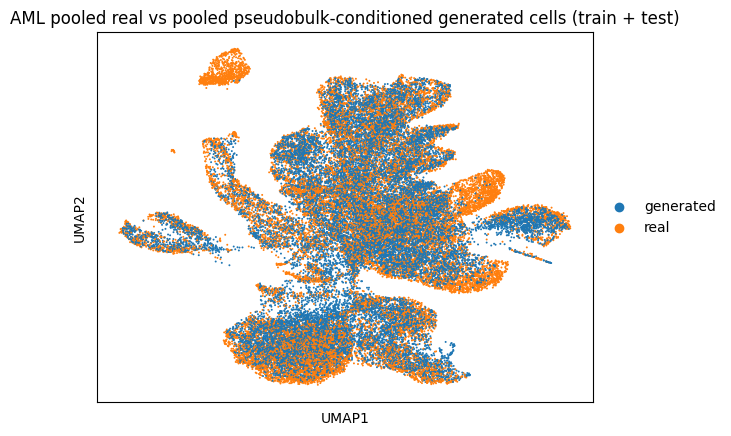

In [34]:
sc.pl.umap(
    adata_global,
    color='source',
    size=8,
    title='AML pooled real vs pooled pseudobulk-conditioned generated cells (train + test)',
)

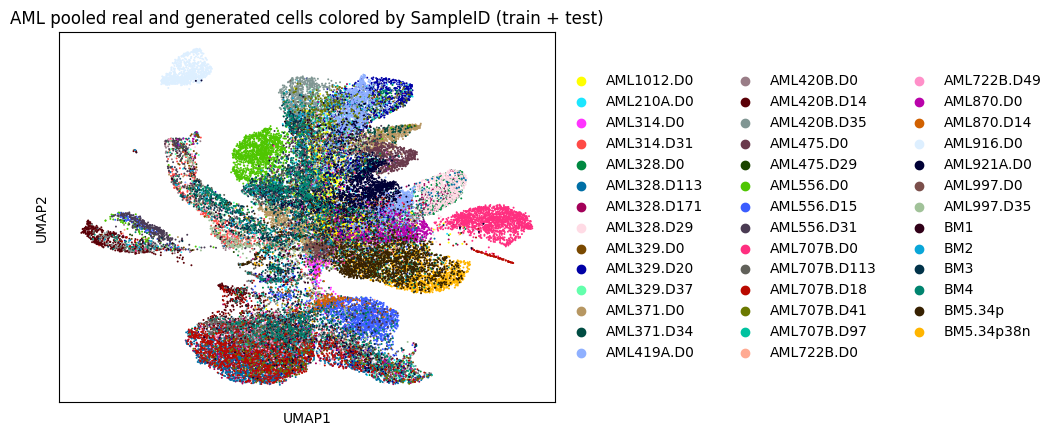

In [35]:
sc.pl.umap(
    adata_global,
    color='sample_id',
    size=8,
    title='AML pooled real and generated cells colored by SampleID (train + test)',
)

The same pooled embedding (`adata_global`), reused as-is. Each panel below still shows every cell for full context, but only one split (train or test) is colored by `source`; the other split is grayed into the background. This makes it possible to check whether real cells that appear unmatched by generated cells in the plot above are disproportionately from the test split.

/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


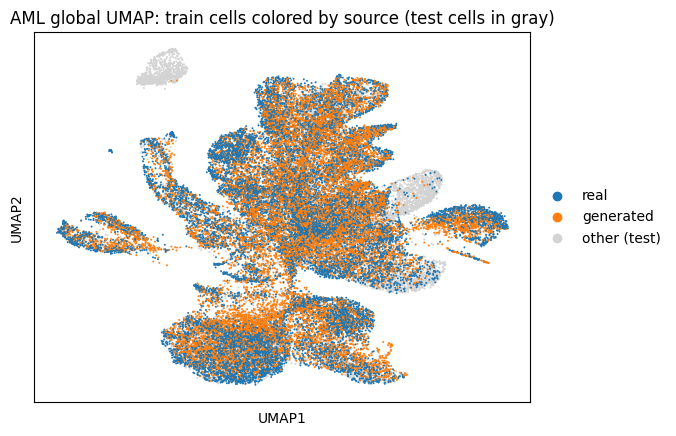

/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


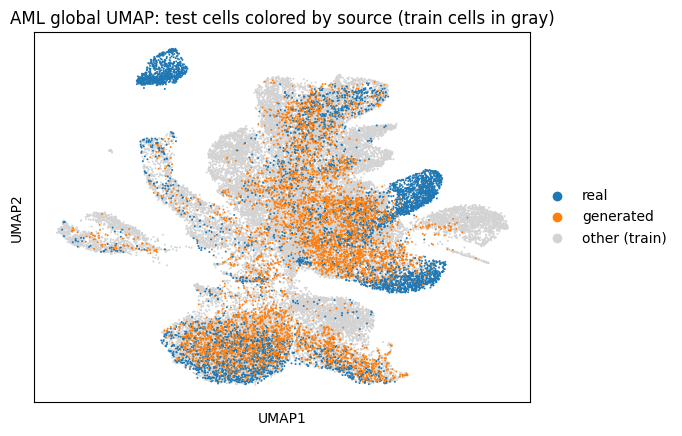

In [36]:
highlight_palette = {'real': '#1f77b4', 'generated': '#ff7f0e'}

for focus_split in ['train', 'test']:
    other_split = 'test' if focus_split == 'train' else 'train'
    is_focus = (adata_global.obs['split'] == focus_split).to_numpy()

    other_label = f'other ({other_split})'
    highlight = adata_global.obs['source'].astype(str).copy()
    highlight[~is_focus] = other_label
    adata_global.obs[f'highlight_{focus_split}'] = pd.Categorical(
        highlight, categories=['real', 'generated', other_label]
    )

    # Draw background cells first so the highlighted split renders on top.
    draw_order = np.argsort(is_focus)
    palette = {**highlight_palette, other_label: 'lightgray'}

    sc.pl.umap(
        adata_global[draw_order],
        color=f'highlight_{focus_split}',
        palette=palette,
        size=8,
        title=f'AML global UMAP: {focus_split} cells colored by source ({other_split} cells in gray)',
    )

## Per-Sample Proxy Pseudobulk Agreement Summary

The summary below uses decoded-cell proxy pseudobulks computed as `log1p(mean(expm1(cell_matrix), axis=0))` for the real and generated cells. This avoids applying the training-time `sum` reduction directly to decoded cell-space values, which is no longer comparable to the stored conditioning pseudobulk after the library-normalization change.


In [37]:
summary_df[['sample_id', 'num_real_cells', 'num_generated_cells', 'conditioning_vs_generated_proxy_pearson', 'conditioning_vs_generated_proxy_spearman', 'real_proxy_vs_generated_proxy_pearson']]


,sample_id,num_real_cells,num_generated_cells,conditioning_vs_generated_proxy_pearson,conditioning_vs_generated_proxy_spearman,real_proxy_vs_generated_proxy_pearson
0,AML1012.D0,1123,1123,0.960284,0.950371,0.960399
1,AML210A.D0,719,719,0.940311,0.948920,0.941961
2,AML314.D0,161,161,0.943608,0.889327,0.943029
3,AML314.D31,336,336,0.947563,0.944834,0.955953
4,AML328.D0,1061,1061,0.926405,0.943714,0.930762
5,AML328.D113,2005,2005,0.956552,0.965007,0.958465
6,AML328.D171,1343,1343,0.946098,0.951968,0.947580
7,AML328.D29,1852,1852,0.912671,0.939677,0.920045
8,AML329.D0,510,510,0.956675,0.953574,0.959196
9,AML329.D20,932,932,0.958603,0.964418,0.960502


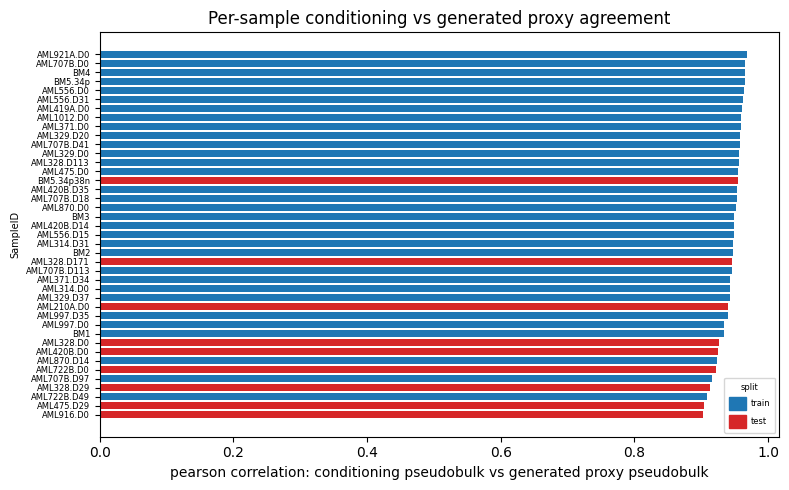

In [38]:
split_colors = {'train': '#1f77b4', 'test': '#d62728'}

plt.figure(figsize=(8, 5))
plot_df = summary_df.sort_values('conditioning_vs_generated_proxy_pearson')
bar_colors = plot_df['split'].map(split_colors)
plt.barh(plot_df['sample_id'], plot_df['conditioning_vs_generated_proxy_pearson'], color=bar_colors)
plt.xlabel('pearson correlation: conditioning pseudobulk vs generated proxy pseudobulk')
plt.ylabel('SampleID', fontsize=7)
plt.tick_params(axis='y', labelsize=6)
plt.title('Per-sample conditioning vs generated proxy agreement')
# legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in split_colors.values()]
# plt.legend(legend_handles, split_colors.keys(), title='split', loc='lower right', fontsize='small')
legend_handles = [plt.Rectangle((0, 0), 1, 1, color=color) for color in split_colors.values()]
plt.legend(
    legend_handles, split_colors.keys(),
    title='split',
    loc='lower right',
    fontsize=6,           
    title_fontsize=6,     
    handlelength=2,     
    handleheight=2,     
    borderpad=0.6,        
    labelspacing=0.6,     
    handletextpad=0.6     
)
plt.tight_layout()
plt.show()


## Per-Sample UMAP: Seurat Dispersion-Based HVG

HVG selection uses `min_mean=0.0125, max_mean=3, min_disp=0.5` (Seurat flavor) on the **joint** real+generated pool.
Dispersion is normalized within mean-expression bins, so genes that vary only due to a systematic real-vs-generated offset
do not pass the `min_disp=0.5` threshold and are excluded from PCA — unlike `cell_ranger` top-N which forces exactly
2000 genes regardless of what drives their variance.

In [39]:
def build_umap_adata_seurat(matrix, obs, n_neighbors=10, n_pcs=20):
    """Build UMAP using Seurat dispersion-based HVG on the joint real+generated pool."""
    mat = np.asarray(matrix, dtype=np.float32)
    mat = np.nan_to_num(mat, nan=0.0, posinf=0.0, neginf=0.0)
    adata_plot = ad.AnnData(mat)
    adata_plot.obs = obs.copy()
    sc.pp.highly_variable_genes(adata_plot, min_mean=0.0125, max_mean=3, min_disp=0.5)
    adata_plot.raw = adata_plot
    adata_plot = adata_plot[:, adata_plot.var.highly_variable].copy()
    sc.pp.scale(adata_plot)
    sc.tl.pca(adata_plot, svd_solver='arpack')
    sc.pp.neighbors(adata_plot, n_neighbors=n_neighbors, n_pcs=min(n_pcs, adata_plot.obsm['X_pca'].shape[1]))
    sc.tl.umap(adata_plot)
    return adata_plot

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


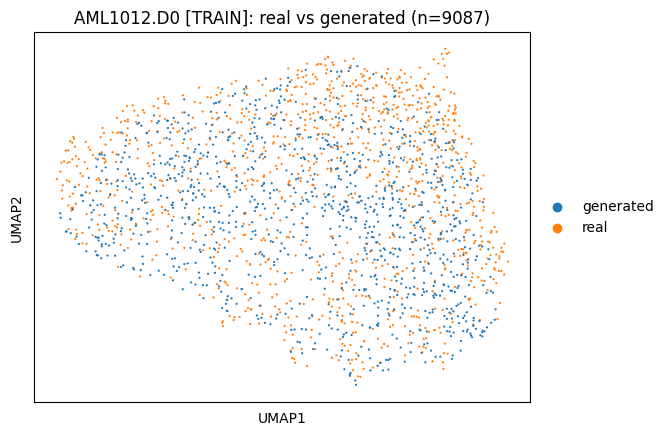

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


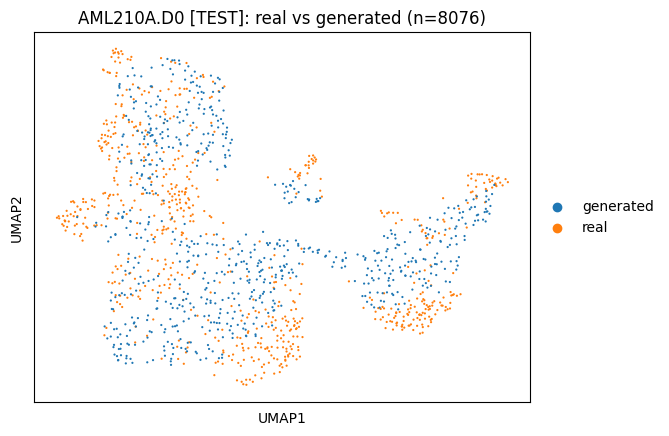

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


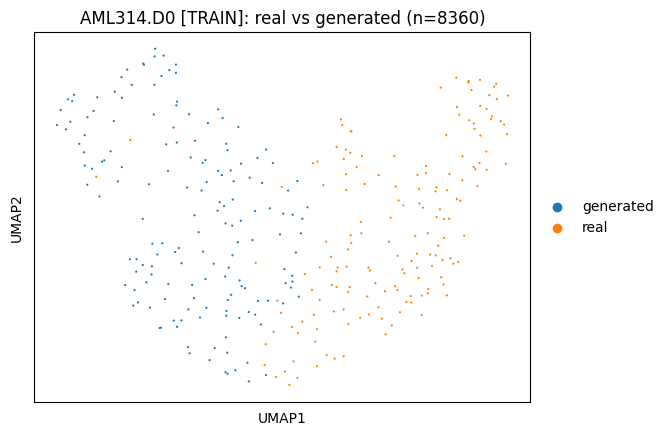

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


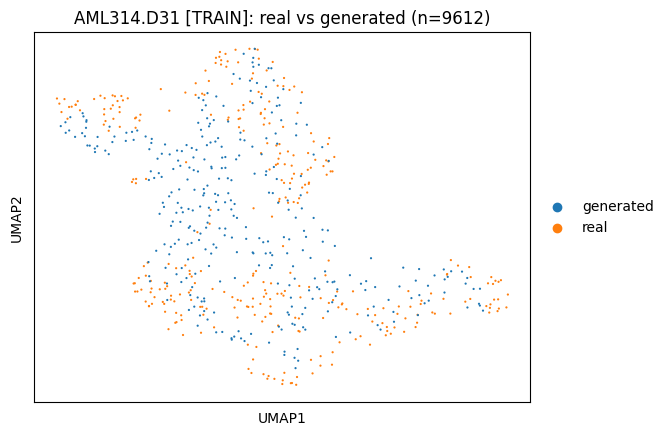

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


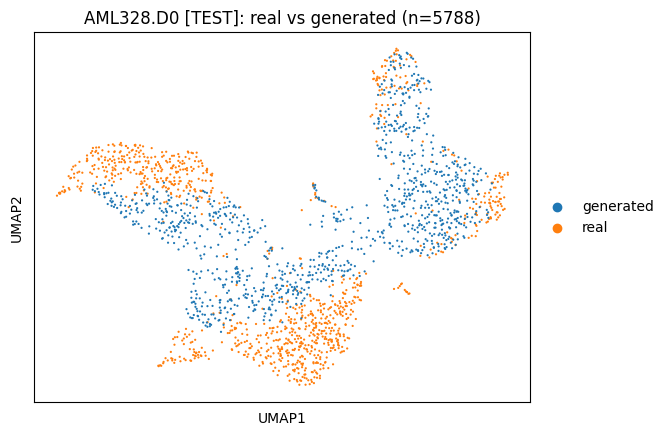

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


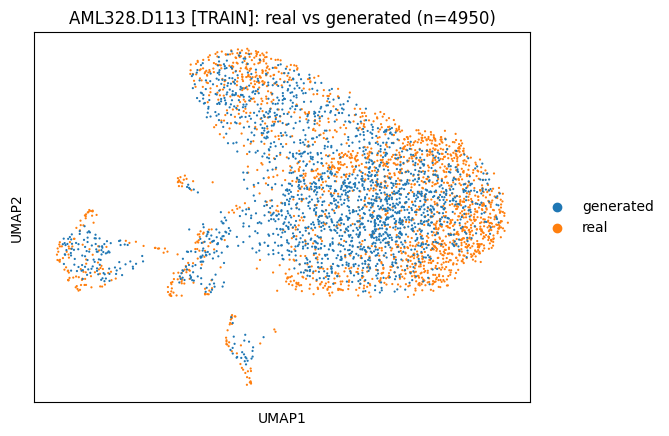

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


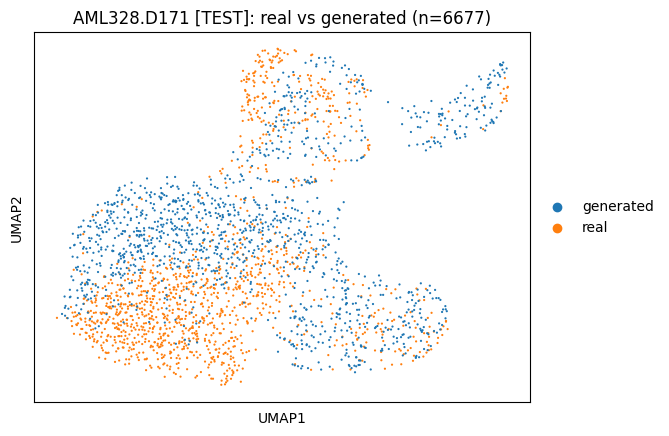

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


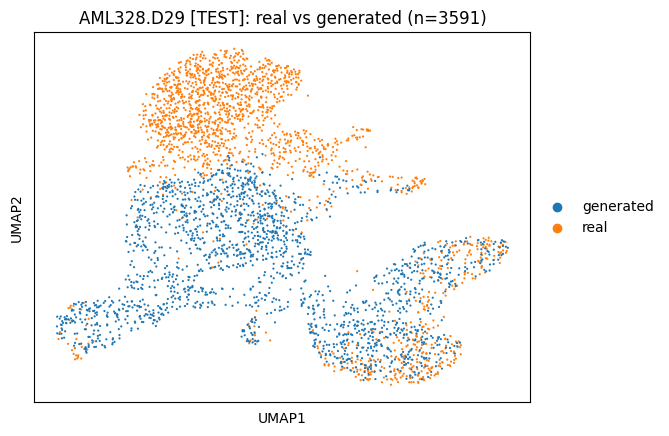

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


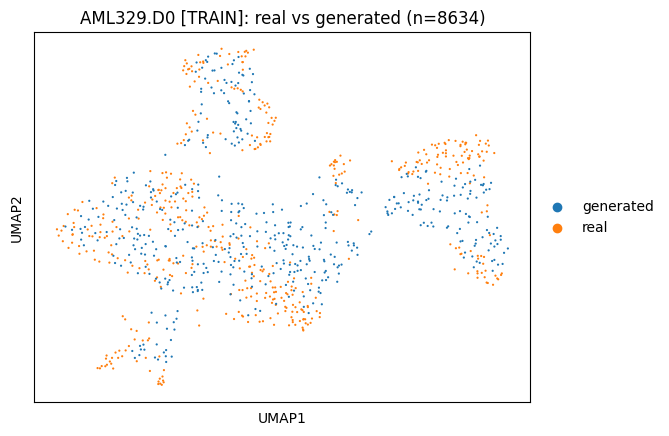

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


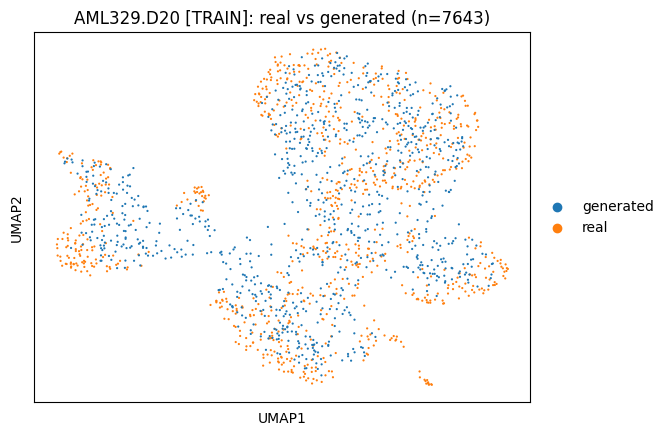

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


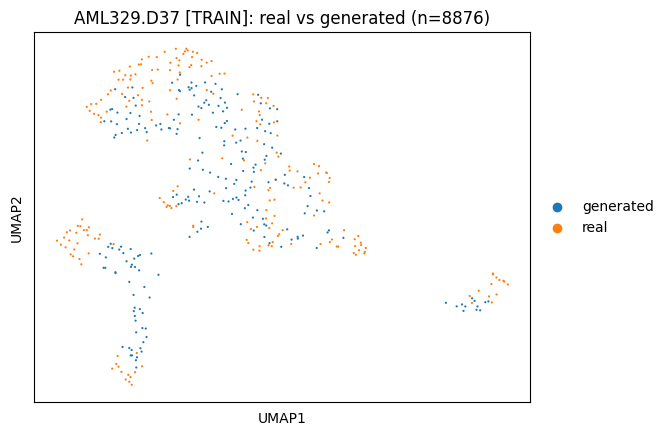

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


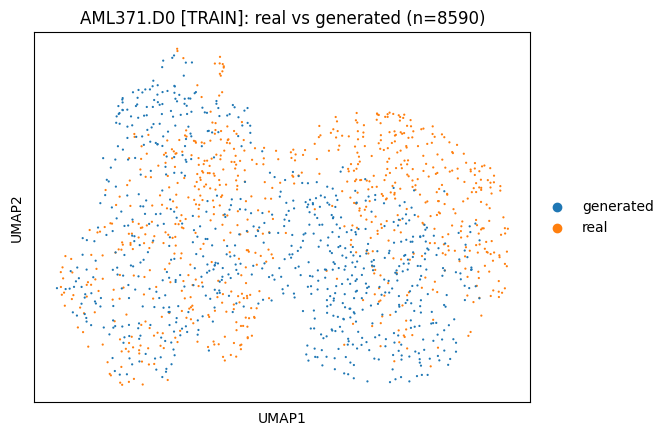

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


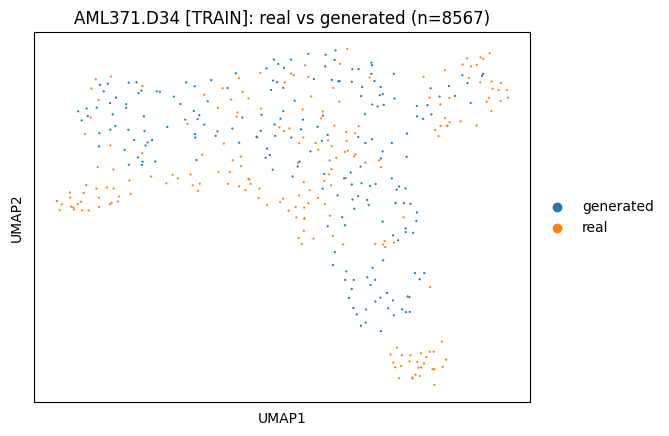

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


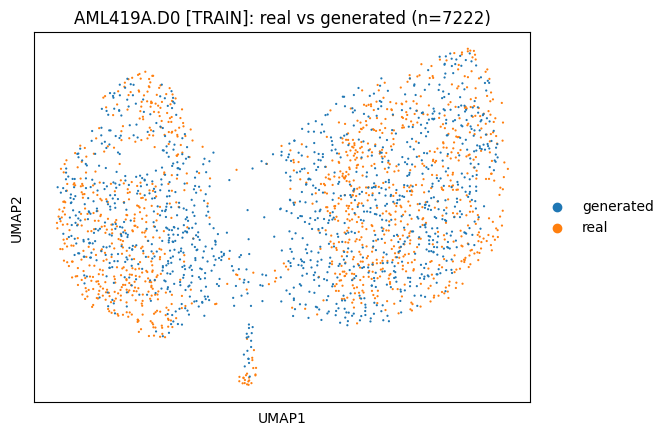

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


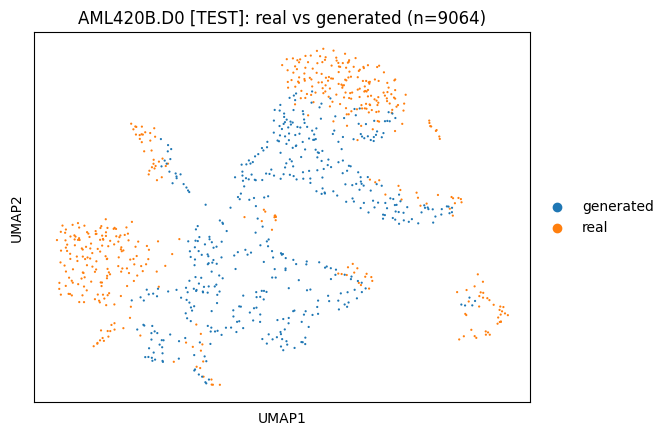

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


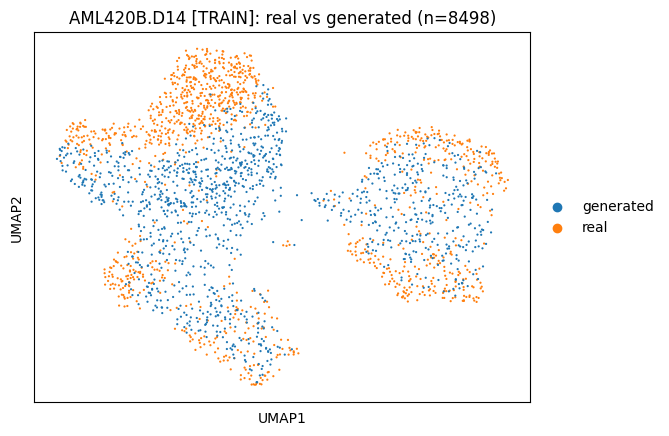

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


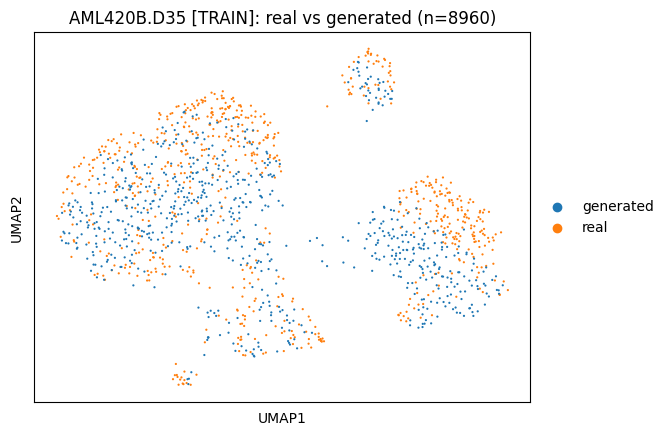

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


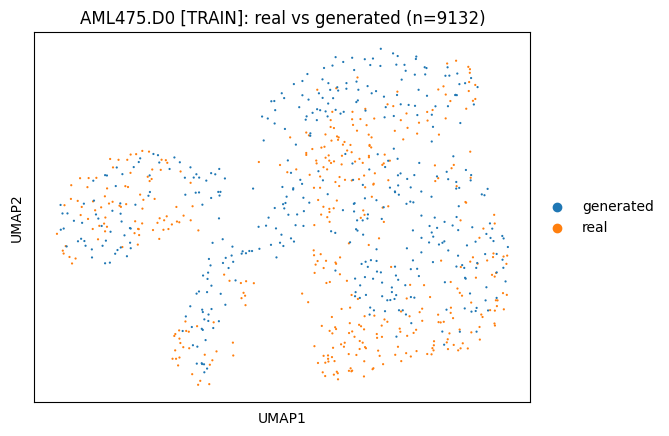

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


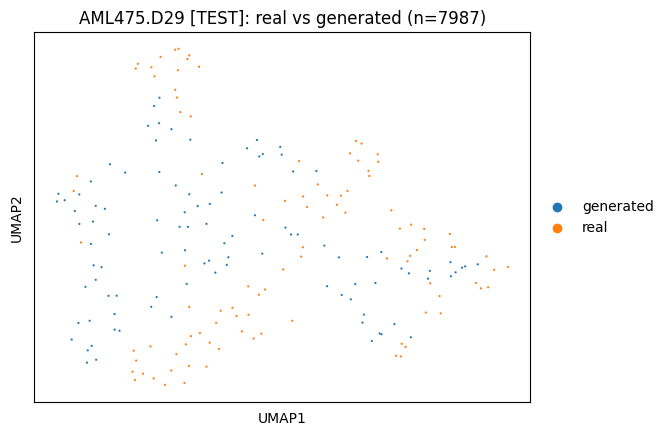

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


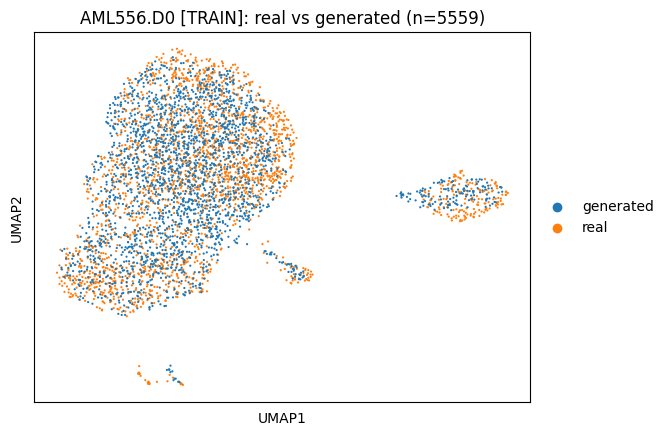

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


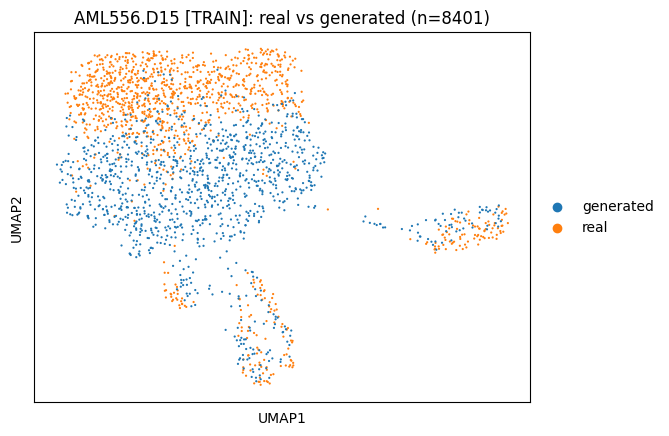

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


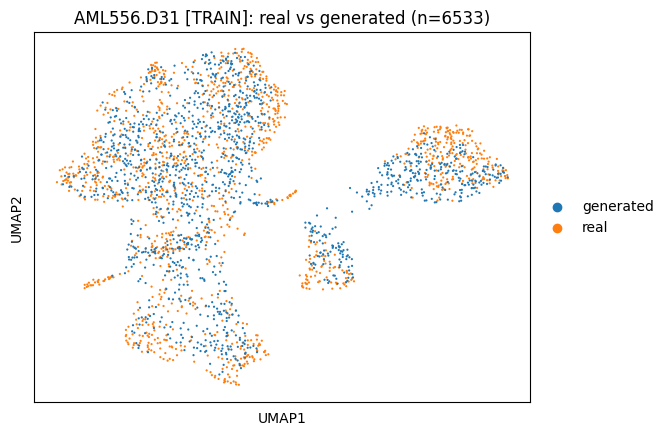

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


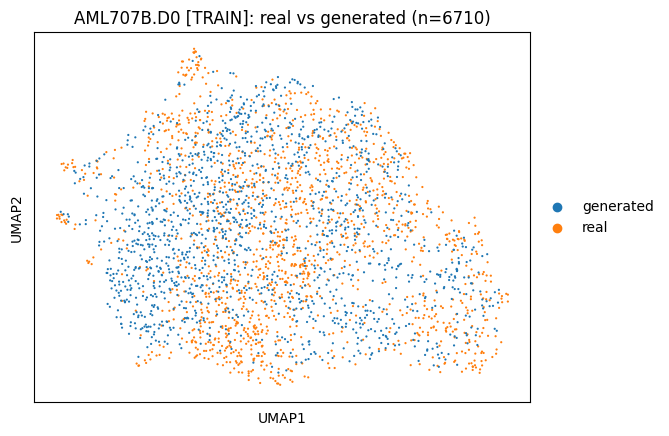

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


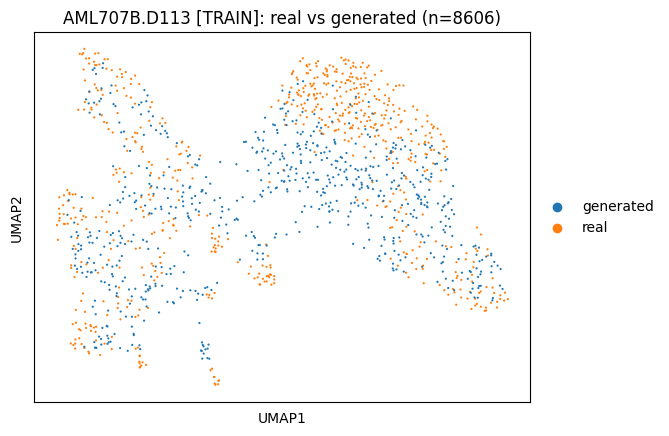

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


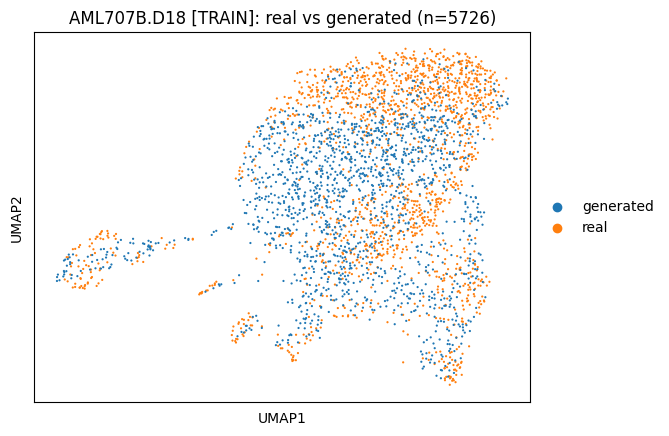

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


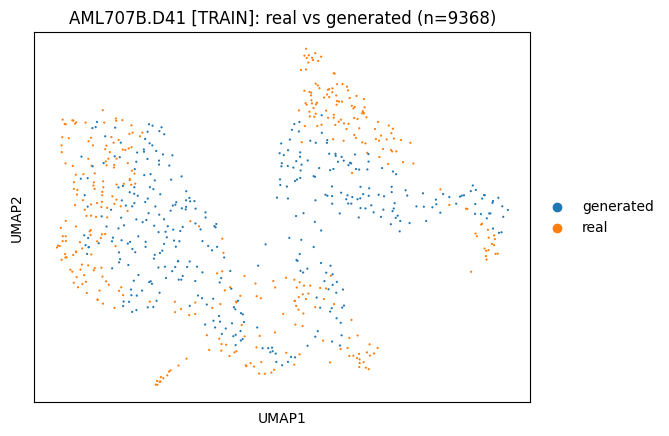

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


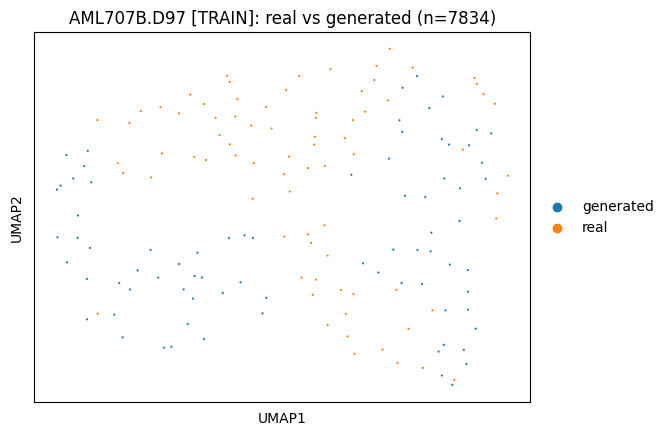

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


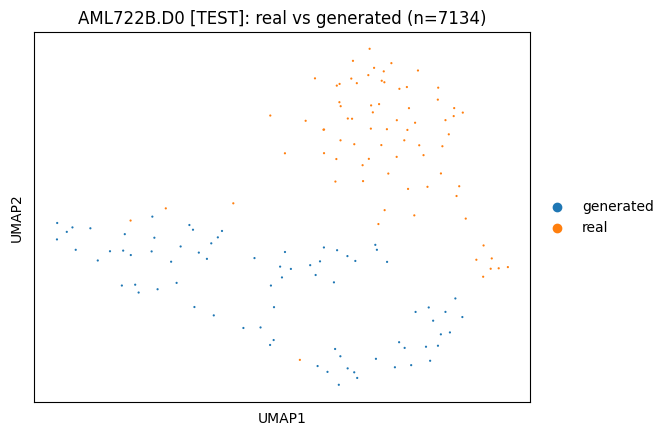

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


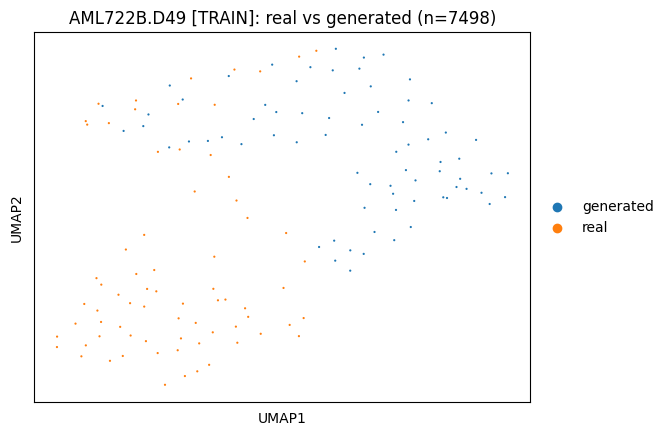

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


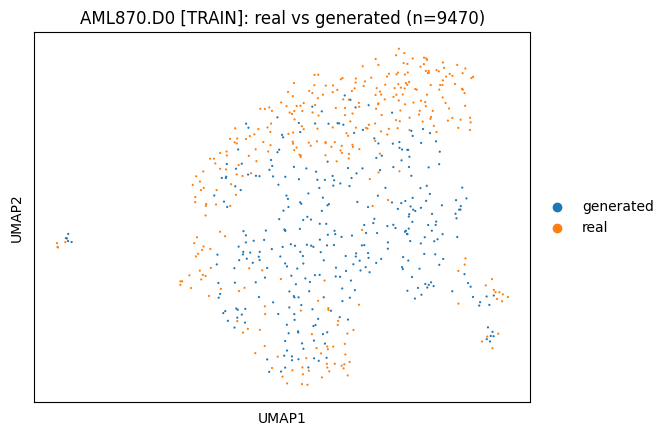

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


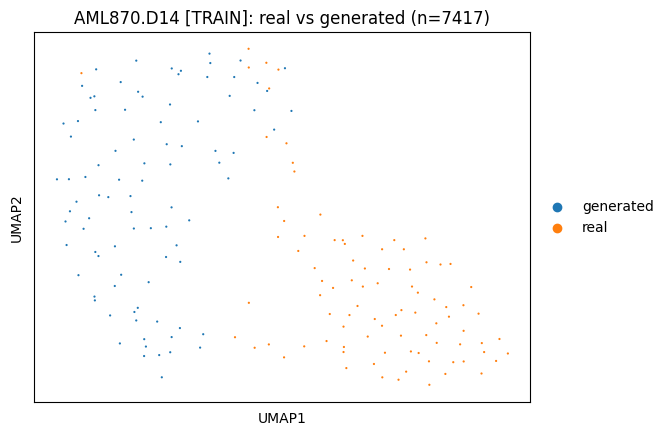

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


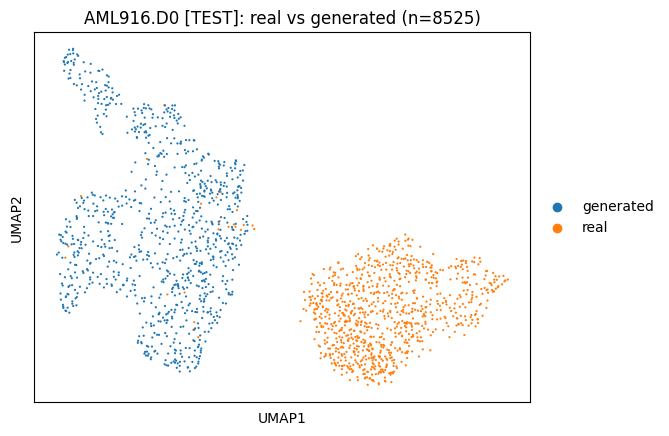

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


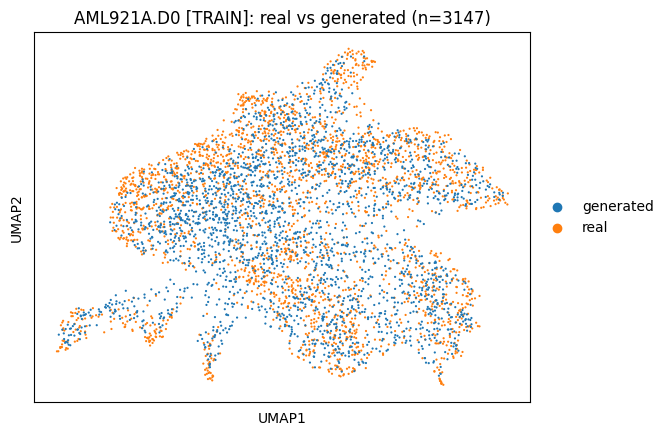

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


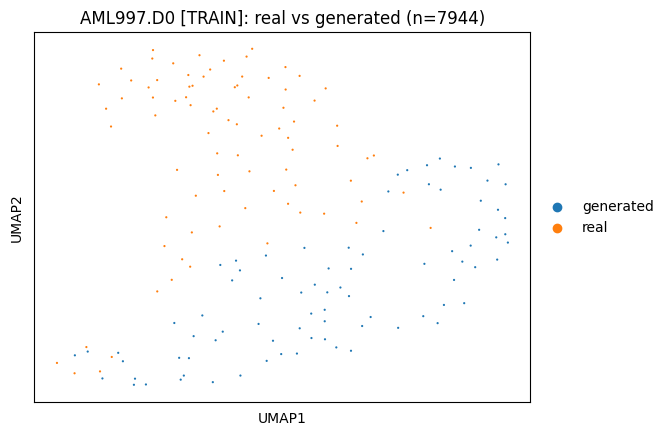

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


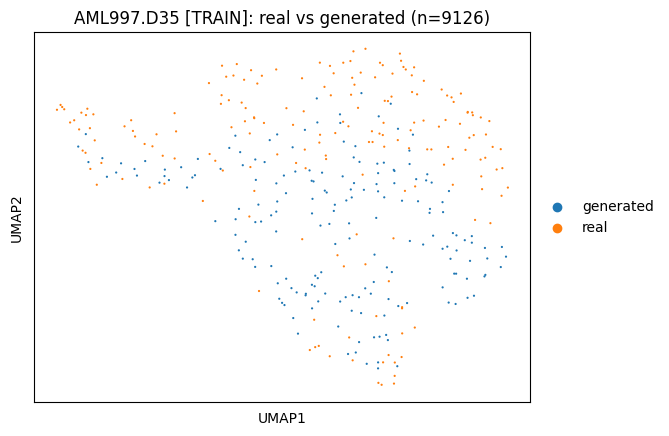

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


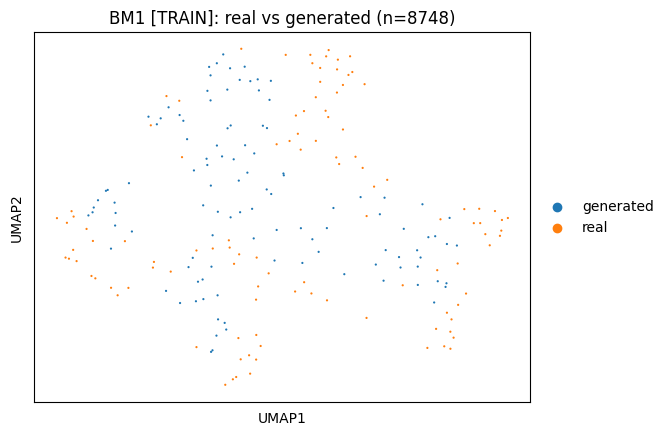

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


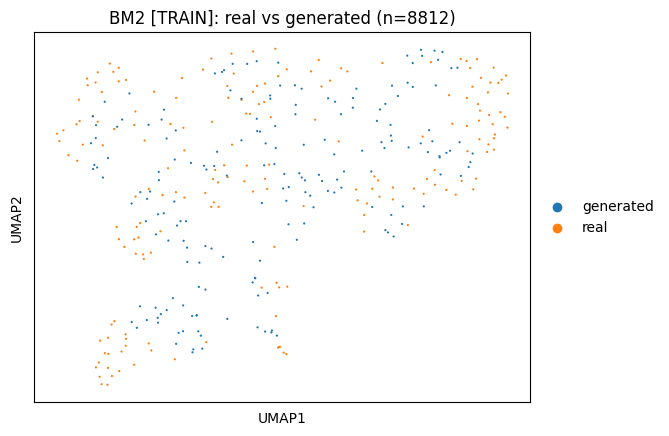

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


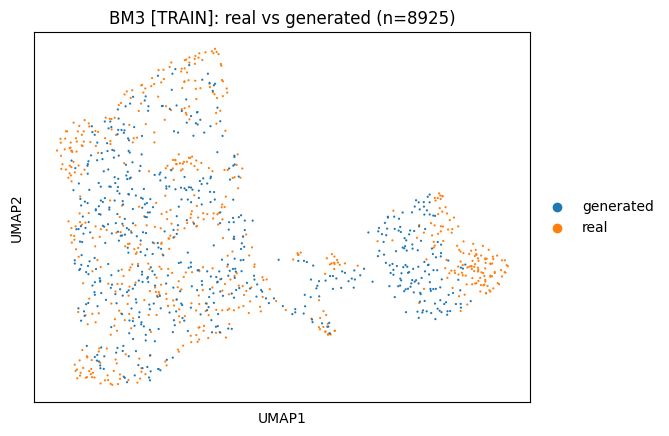

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


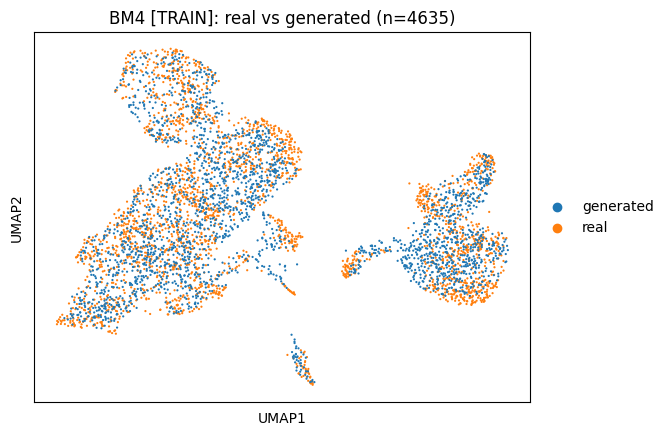

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


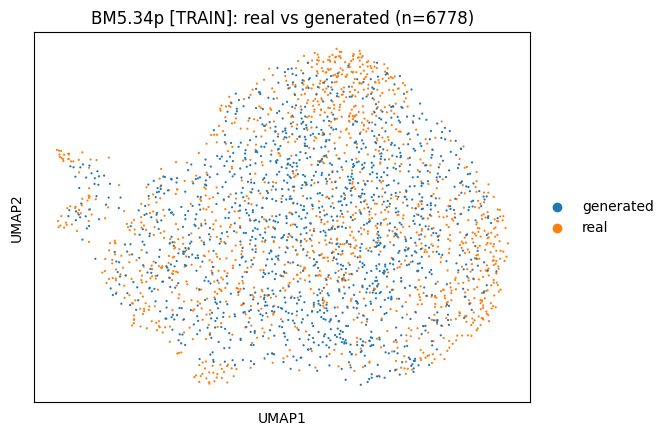

/share/home/xiaojied/.local/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:208: RuntimeWarning: invalid value encountered in log
  dispersion = np.log(dispersion)
/share/home/xiaojied/.local/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


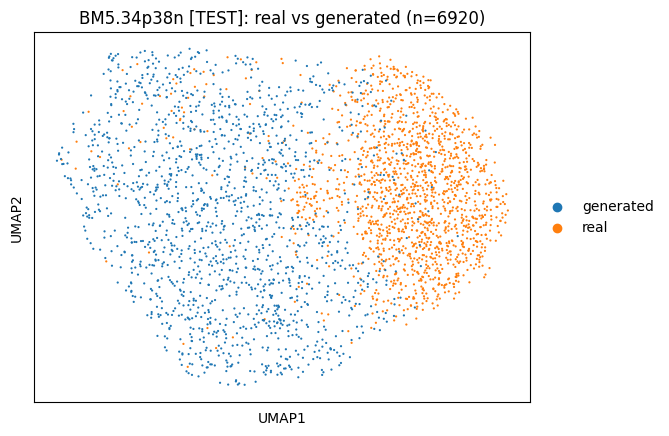

In [40]:
for sample_id in sorted(generated_by_sample):
    payload = generated_by_sample[sample_id]
    split = payload['split']

    real_sub, _ = subsample_array(payload['real_cells'],      max_cells_per_sample_plot, seed=random_seed)
    gen_sub,  _ = subsample_array(payload['generated_cells'], max_cells_per_sample_plot, seed=random_seed + 1)

    combined = np.concatenate((real_sub, gen_sub), axis=0)
    obs = pd.DataFrame({
        'source': pd.Categorical(['real'] * real_sub.shape[0] + ['generated'] * gen_sub.shape[0]),
    })

    adata_sample = build_umap_adata_seurat(combined, obs)
    n_hvg = adata_sample.n_vars
    title = f'{sample_id} [{split.upper()}]: real vs generated (n={n_hvg})'
    sc.pl.umap(adata_sample, color='source', size=10, title=title)

## Per-Sample UMAP: VAE Latent Space (Joint Embedding)

Real cells are encoded by the VAE encoder; generated latents come directly from the diffusion model.
UMAP is run jointly on the combined 128-dim latent pool — both groups compete equally in the neighbor graph.
This is the most direct diagnostic: if the diffusion model is faithful, real and generated latents overlap here.
If they overlap here but not in the gene-space UMAP above, the issue is in the decoder, not the diffusion model.

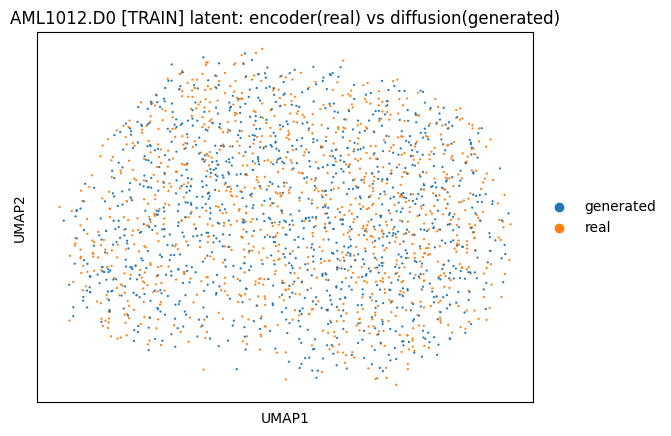

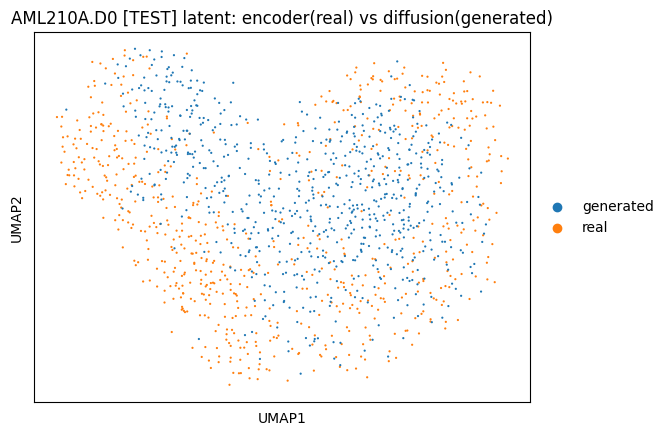

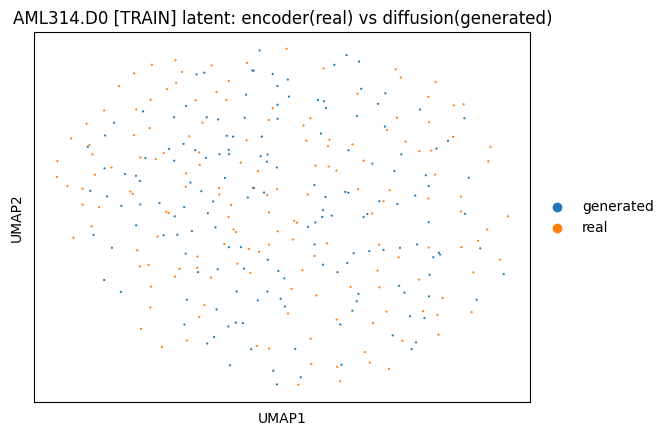

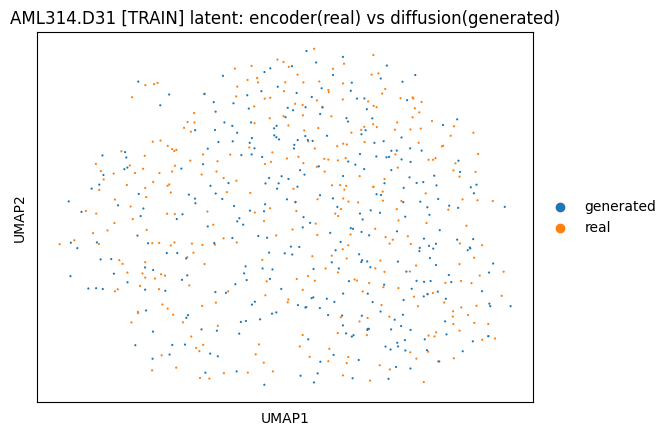

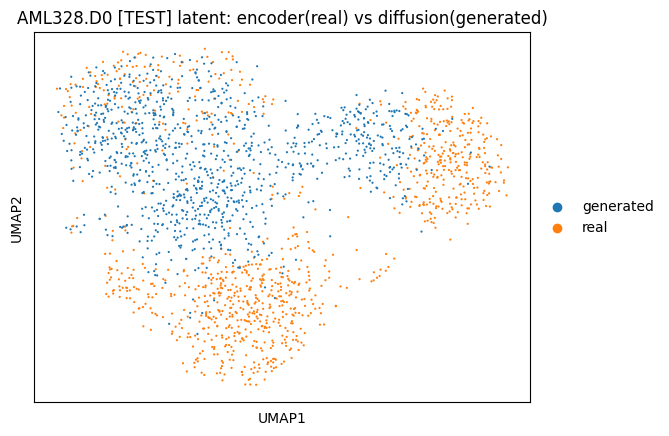

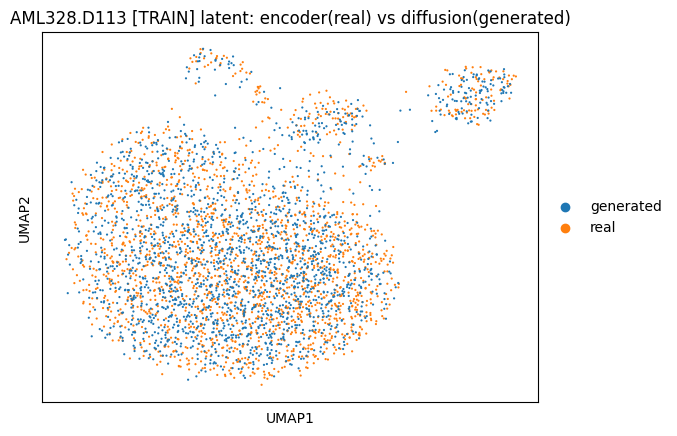

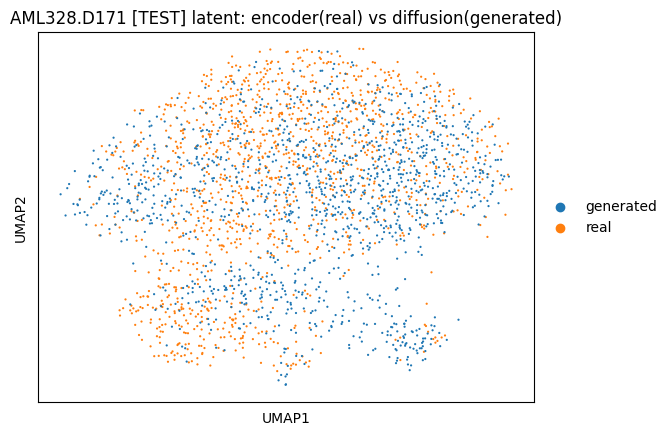

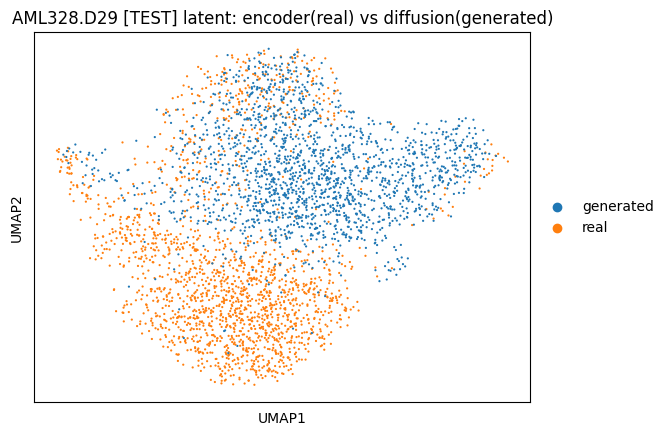

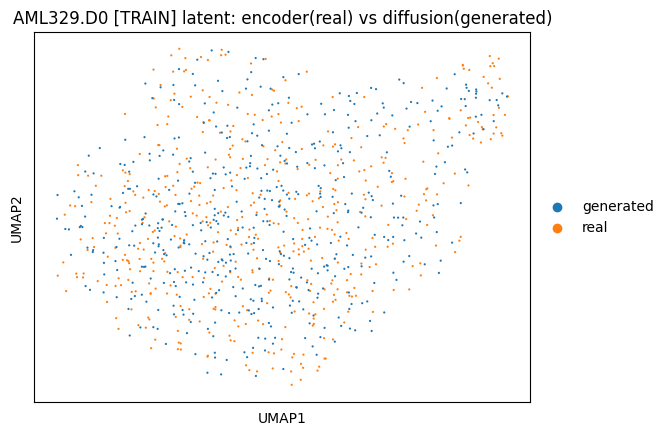

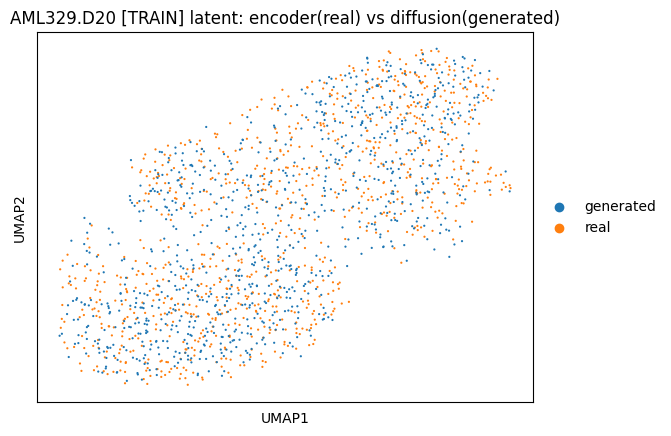

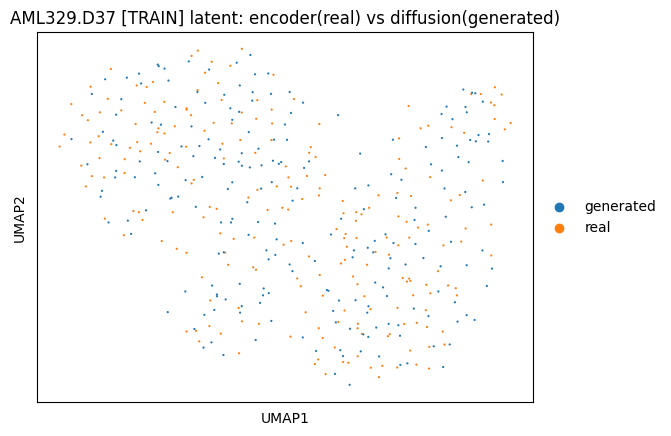

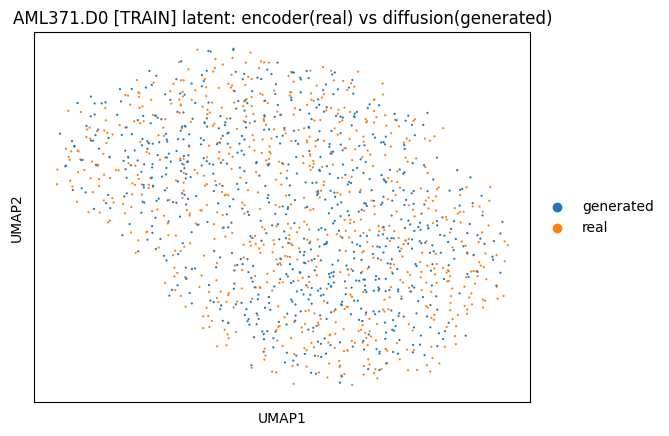

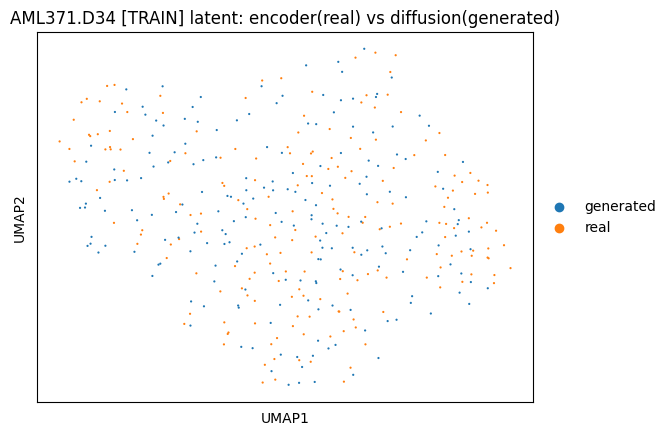

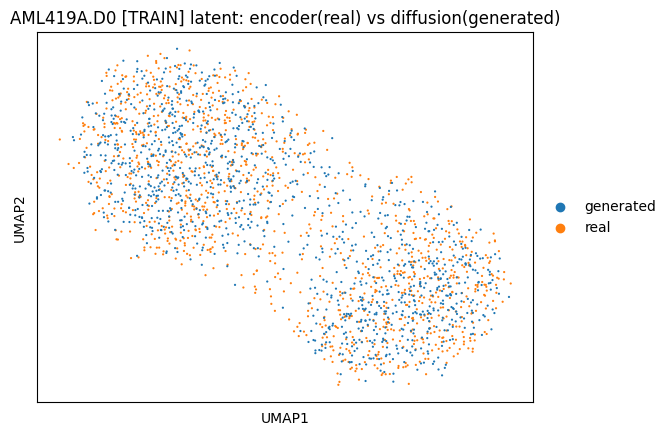

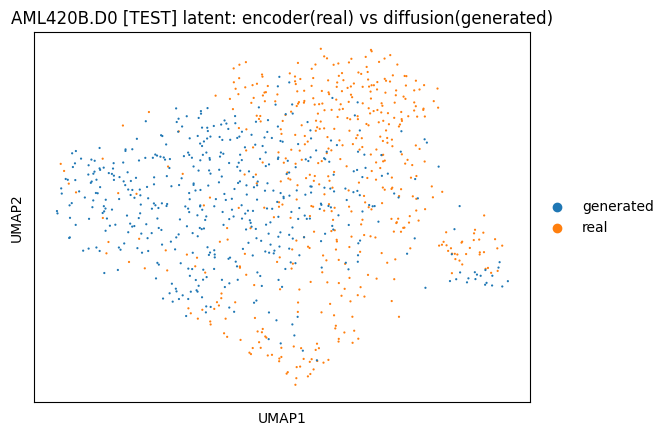

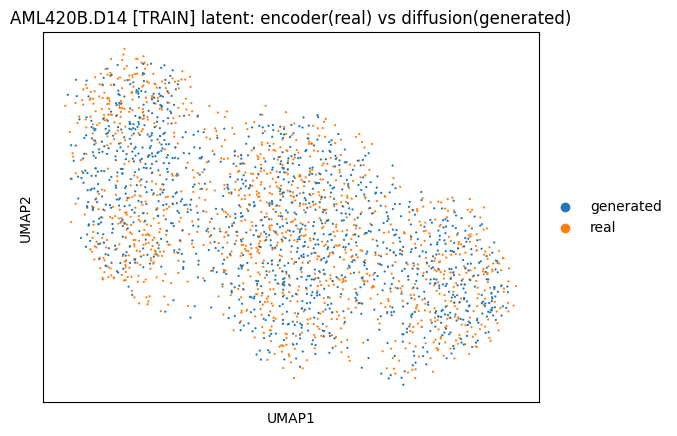

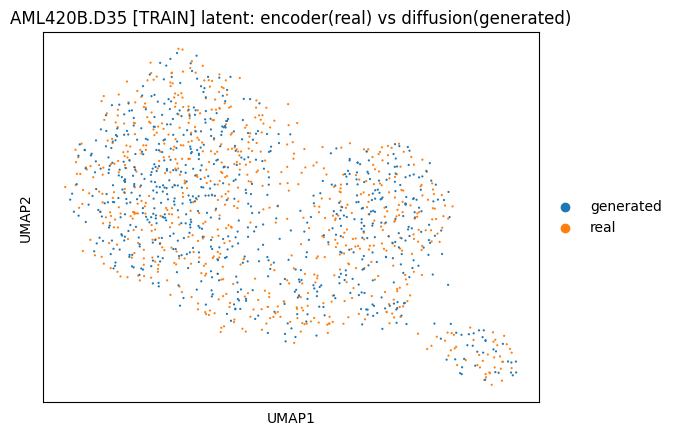

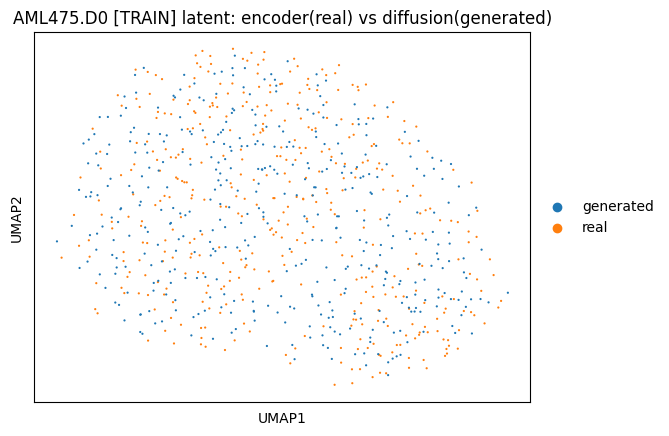

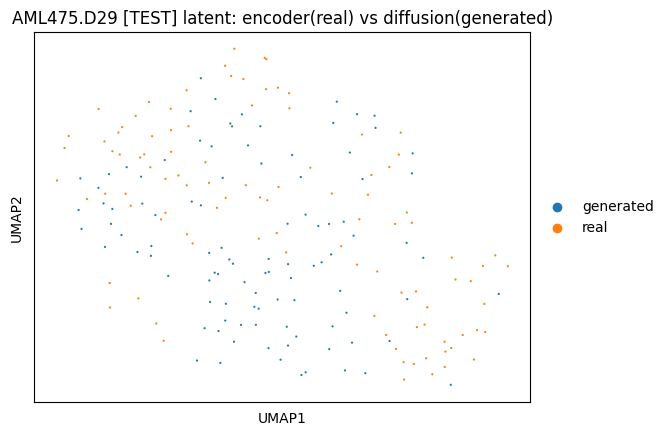

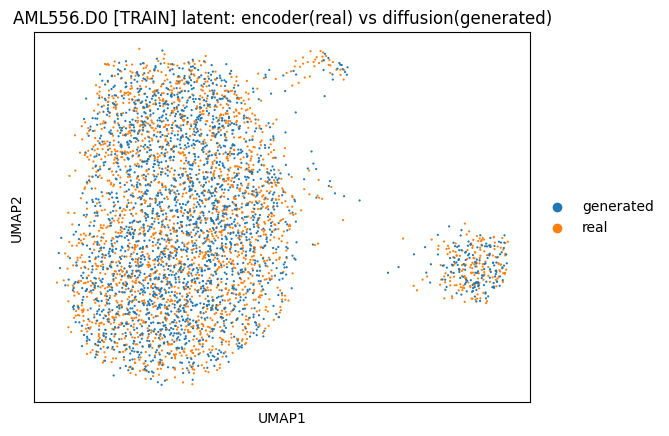

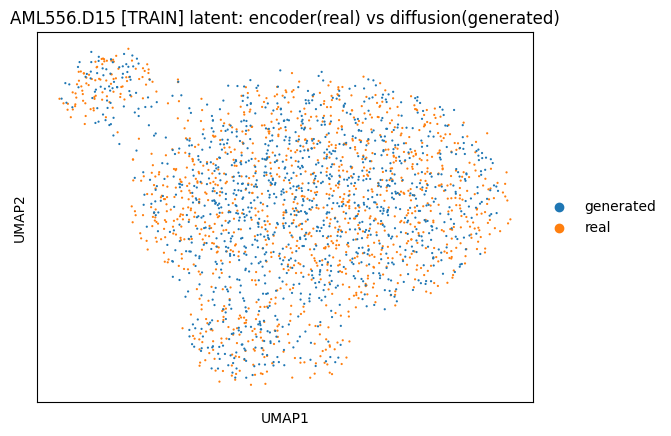

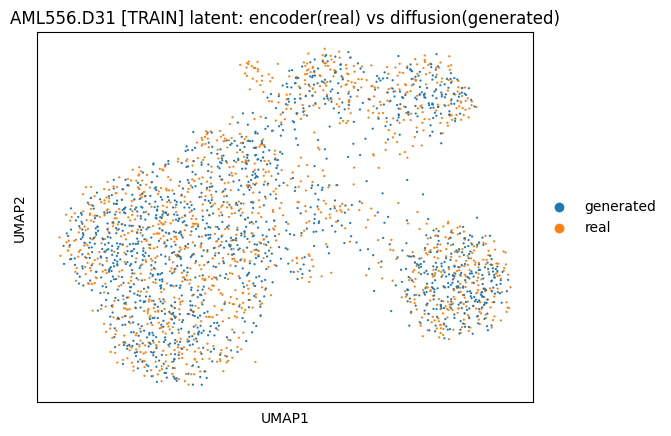

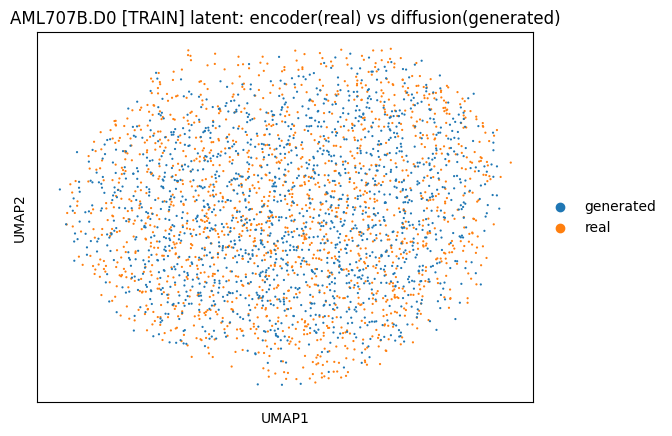

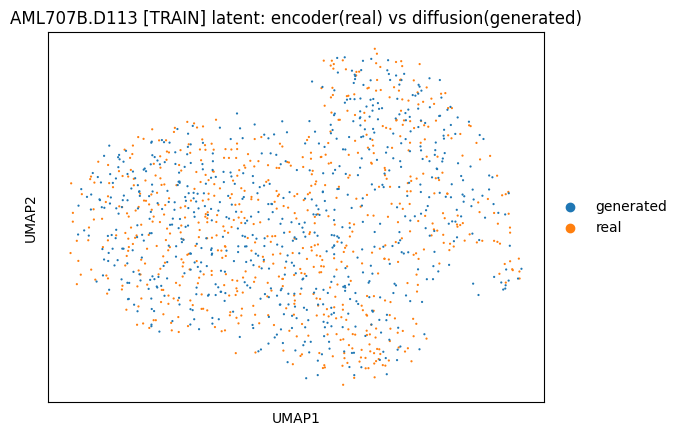

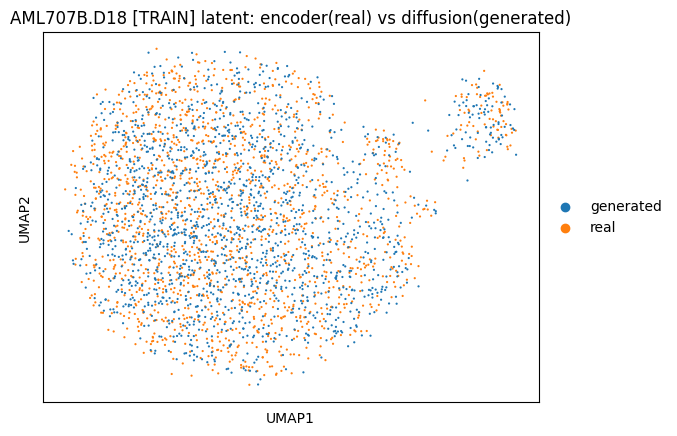

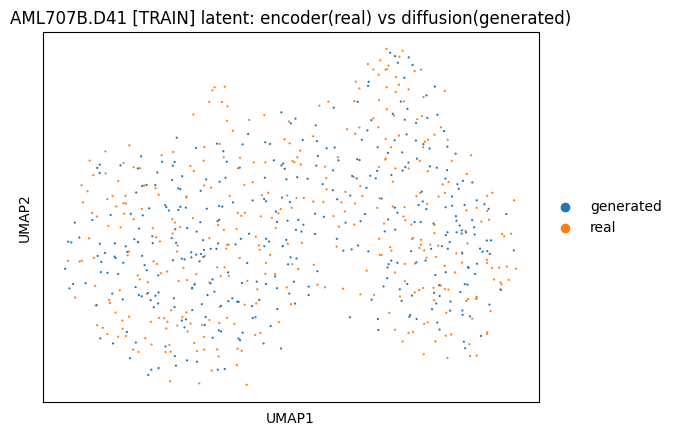

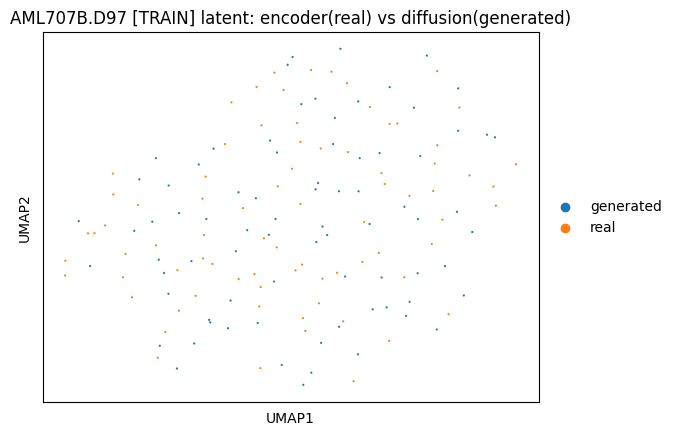

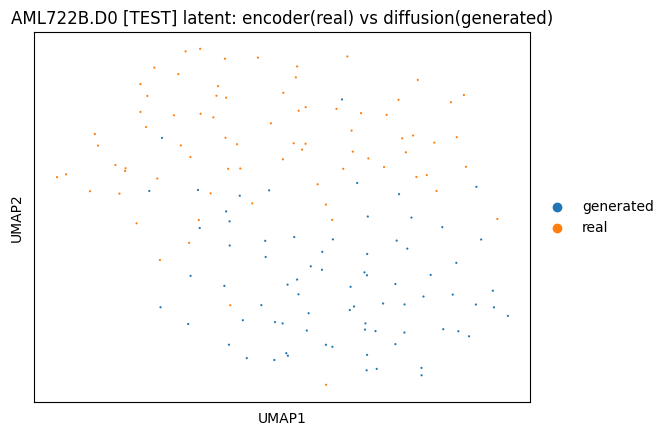

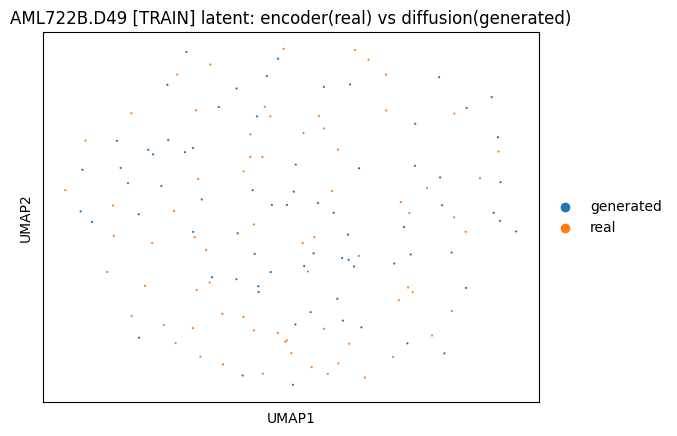

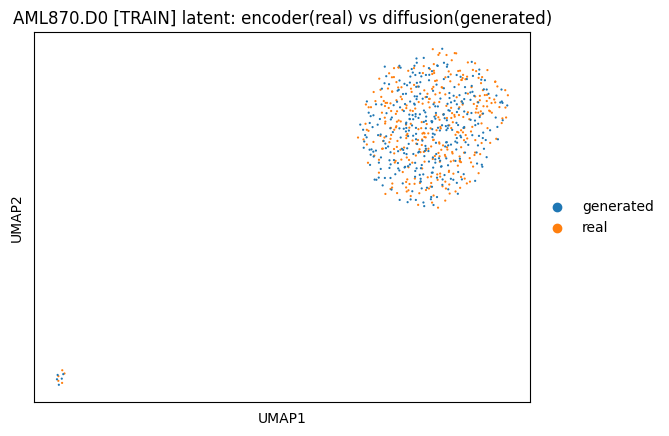

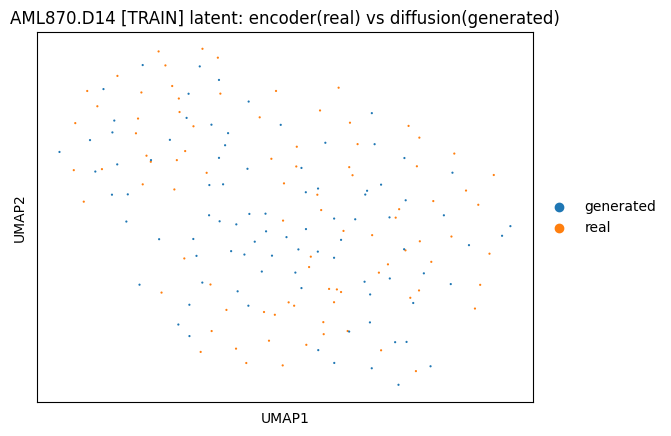

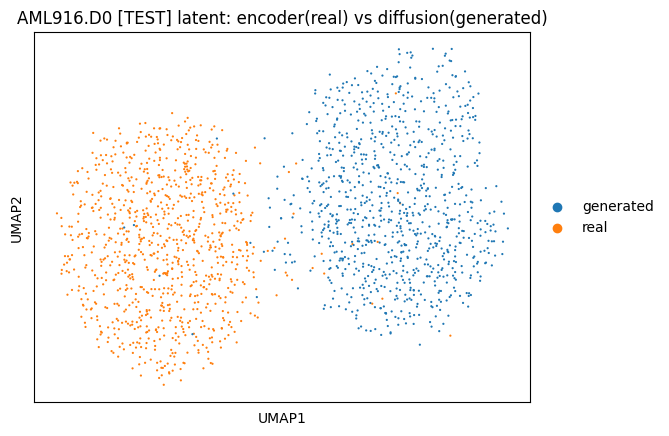

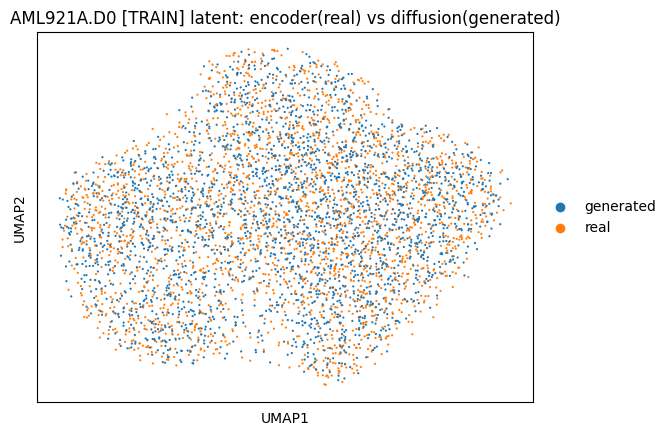

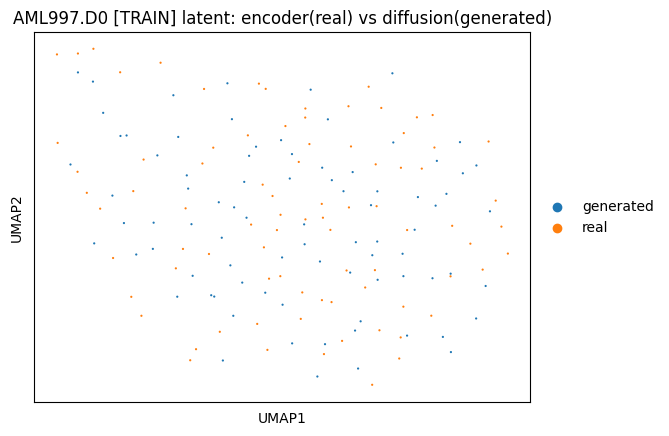

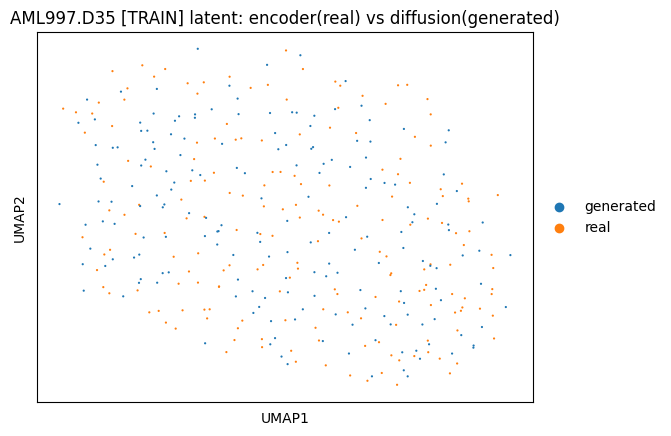

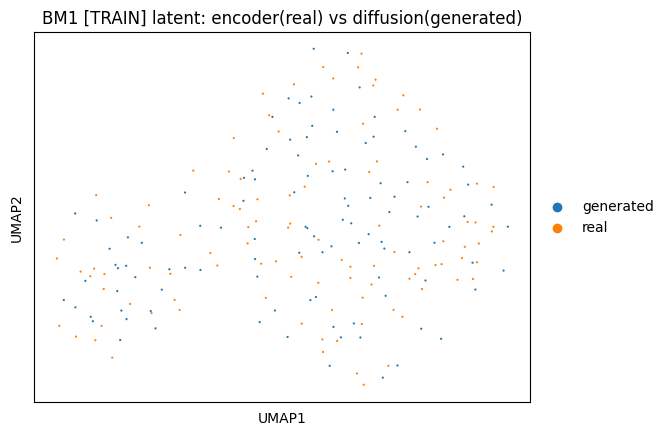

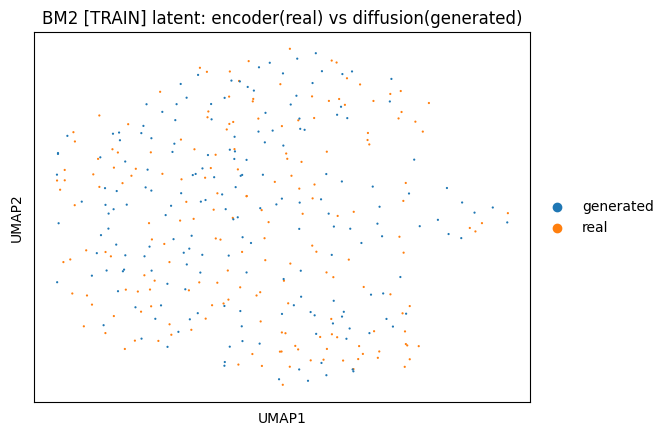

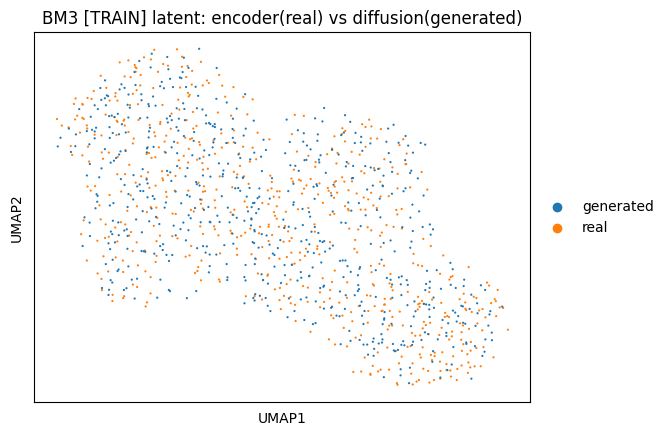

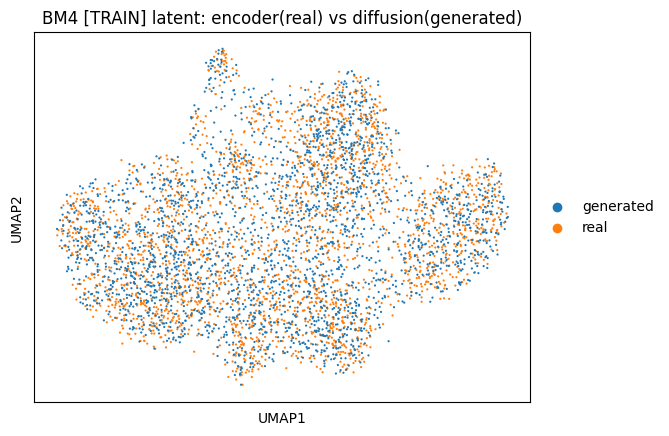

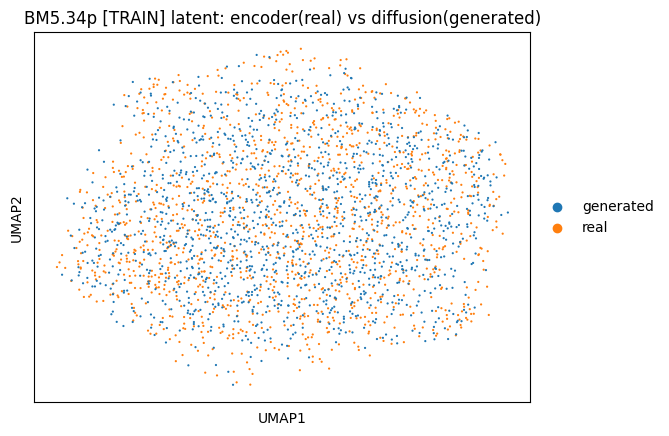

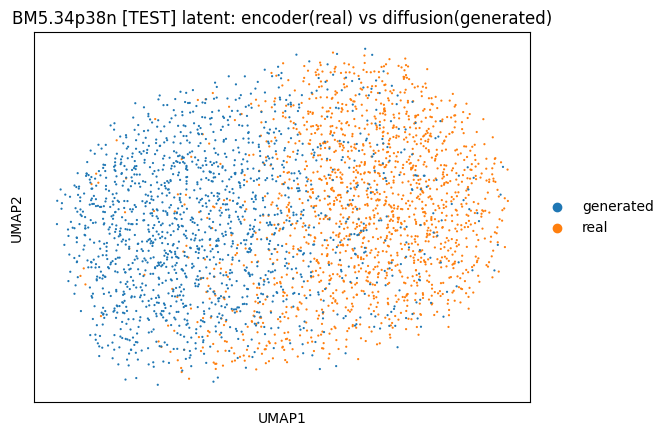

In [41]:
for sample_id in sorted(generated_by_sample):
    payload = generated_by_sample[sample_id]
    split = payload['split']
    real_sub, _    = subsample_array(payload['real_cells'],        max_cells_per_sample_plot, seed=random_seed)
    gen_lat_sub, _ = subsample_array(payload['generated_latents'], max_cells_per_sample_plot, seed=random_seed + 1)

    obs_real = pd.DataFrame({'source': pd.Categorical(['real']      * real_sub.shape[0])})
    obs_gen  = pd.DataFrame({'source': pd.Categorical(['generated'] * gen_lat_sub.shape[0])})

    adata_sample = build_umap_latent(real_sub, gen_lat_sub, obs_real, obs_gen, vae_path=vae_path)
    title = f'{sample_id} [{split.upper()}] latent: encoder(real) vs diffusion(generated)'
    sc.pl.umap(adata_sample, color='source', size=10, title=title)

## Optional: Inspect One Sample In More Detail

Set `focus_sample_id` below to inspect its conditioning-vs-generated proxy scatter plot and the largest gene-level proxy differences.


In [42]:
focus_sample_id = summary_df.loc[0, 'sample_id'] if len(summary_df) else None
focus_sample_id


'AML1012.D0'

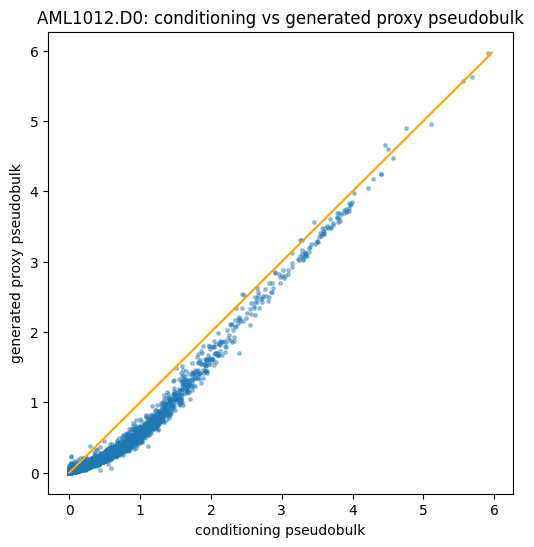

,gene,conditioning_pseudobulk,real_proxy_pseudobulk,generated_proxy_pseudobulk,abs_conditioning_generated_proxy_diff
3559,CXCL8,1.115695,1.178645,0.384138,0.731557
10789,MPO,2.390569,2.345784,1.697117,0.693452
8505,CLEC4OP,1.253351,1.296297,0.601845,0.651506
14197,RNASE2,1.699811,1.700707,1.052437,0.647374
18686,XIST,1.253351,1.294666,0.614574,0.638778
1191,ATP5F1C,1.404075,1.351567,0.771874,0.632201
13593,PTTG1IP,1.600822,1.611876,0.969257,0.631565
4874,FABP5,1.340657,1.298325,0.719887,0.620770
10448,MGST1,1.361589,1.328795,0.753251,0.608338
2068,CALCOCO2,1.562836,1.584946,0.958255,0.604581


In [43]:
if focus_sample_id is not None:
    payload = generated_by_sample[focus_sample_id]
    plt.figure(figsize=(6, 6))
    x = payload['input_pseudobulk']
    y = payload['generated_proxy_pseudobulk']
    xy_min = float(min(x.min(), y.min()))
    xy_max = float(max(x.max(), y.max()))
    plt.scatter(x, y, s=6, alpha=0.4)
    plt.plot([xy_min, xy_max], [xy_min, xy_max], color='orange')
    plt.xlabel('conditioning pseudobulk')
    plt.ylabel('generated proxy pseudobulk')
    plt.title(f'{focus_sample_id}: conditioning vs generated proxy pseudobulk')
    plt.show()

    gene_diff = pd.DataFrame({
        'gene': gene_names,
        'conditioning_pseudobulk': payload['input_pseudobulk'],
        'real_proxy_pseudobulk': payload['real_proxy_pseudobulk'],
        'generated_proxy_pseudobulk': payload['generated_proxy_pseudobulk'],
    })
    gene_diff['abs_conditioning_generated_proxy_diff'] = (gene_diff['conditioning_pseudobulk'] - gene_diff['generated_proxy_pseudobulk']).abs()
    display(gene_diff.sort_values('abs_conditioning_generated_proxy_diff', ascending=False).head(20))
